# ANÁLISES - MÚLTIPLAS REALIZAÇÕES

#### Objetivo: observar o comportamento da distribuição a posteriori p(**B**|**X**) para diferentes realizações dos sinais das fontes e misturas.

#### Análises:
 - *Curvas de nível:* pontos de máximo de p(**B**|**X**) para várias realizações.
 - *Estimativas MMSE:* distribuições de probabilidade marginais p(*bij*|**X**) para várias realizações.
 - *Erros MMSE:* distribuições do erro de estimação MMSE (eq D.9) para várias realizações.

In [1]:
import os
import pickle
import dill
import pprint
import itertools
import pathos
import pprint
import functools
from functools import partial
from pathlib import Path
import logging
import json

import pandas as pd
import numpy as np
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression as MI

import json
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')
from src import SignalGraphPlotter, ExperimentParser, EstimationGraphPlotter

In [2]:
# TODO rodar com matriz gabarito sendo a identidade
# TODO rodar com outra prior errada
# TODO colocar gabarito nas figuras com modelo errado

# 1. Read and parse raw results

In [3]:
# Experiment name
EXPERIMENT_NAME = 'test_no_map_identity_mixing'

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Directory which holds experiments
experiment_dir = base_output_path / EXPERIMENT_NAME

# Instantiate and execute parser object
parser = ExperimentParser(experiment_dir)
parser.parse(verbose=True)

####################################################################################################
Total of 88 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 12 realizations without executed results
####################################################################################################


# 2. Análises conjuntas

## 2.1. Máximos das curvas de nível

### Mesmo modelo

,test_case,u_mean,v_mean,u_std,v_std
0,i,-0.001591,0.005318,0.015433,0.075723
1,ii,-0.001591,0.005295,0.015433,0.075693
2,iii,-0.001341,0.002977,0.014475,0.036435
3,iv,-0.001341,0.002977,0.014475,0.036435


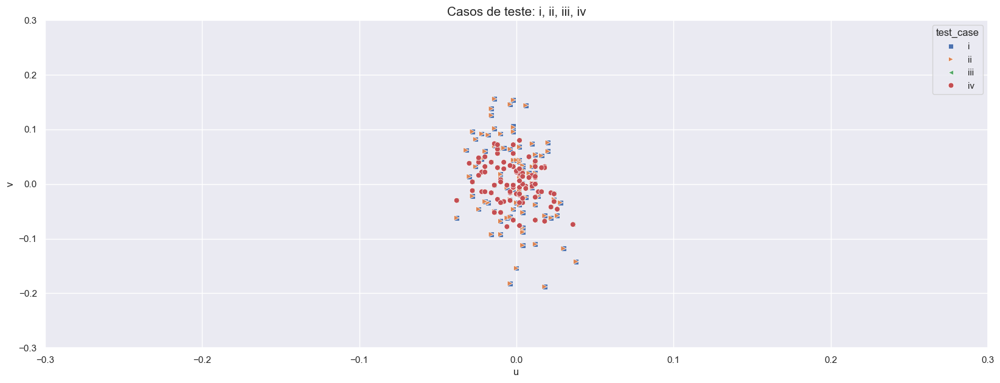

In [4]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['i','ii','iii','iv'],
    # equal_aspect=True,
    # u_range=(-0.15, 0.15),
    # v_range=(-0.2, 0.1),
)

,test_case,u_mean,v_mean,u_std,v_std
0,v,-0.002864,0.002523,0.016074,0.033129
1,vi,-0.002864,0.002523,0.016074,0.033129
2,vii,-0.002727,0.001727,0.015433,0.023864
3,viii,-0.002727,0.001727,0.015433,0.023864


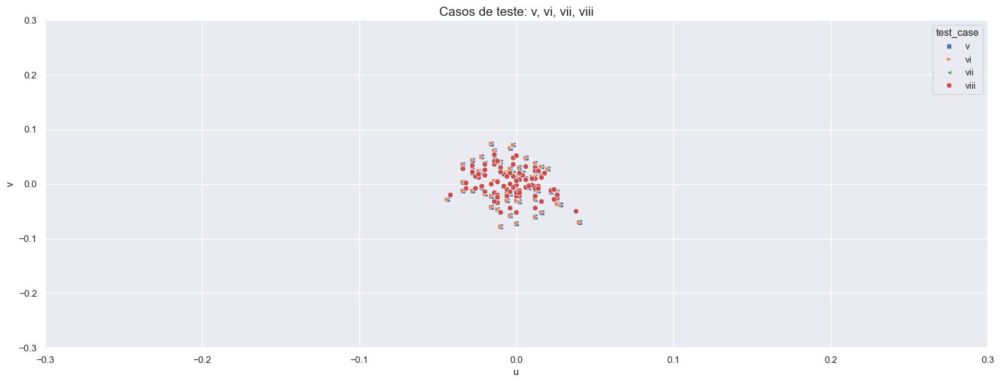

In [5]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,u_mean,v_mean,u_std,v_std
0,ix,0.001659,-0.279614,0.007786,0.109137
1,x,0.001659,-0.279614,0.007786,0.109137
2,xi,0.001477,-0.259227,0.007166,0.151594
3,xii,0.001477,-0.259227,0.007166,0.151594


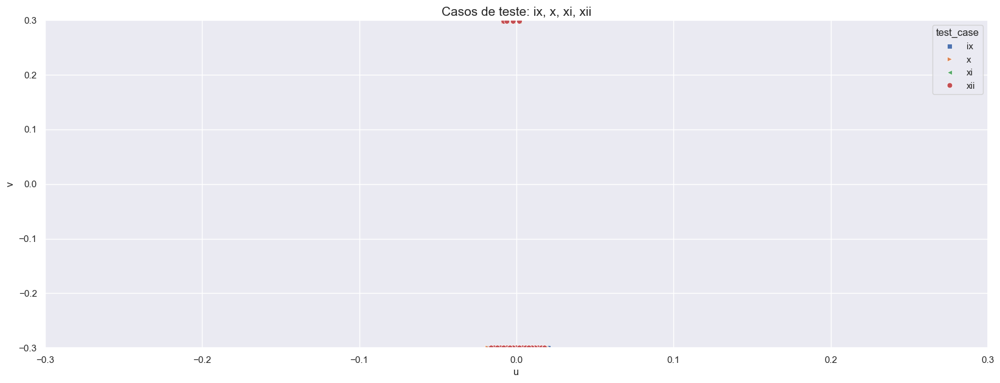

In [6]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,i,-0.001591,0.005318,0.015433,0.075723
1,ix,0.001659,-0.279614,0.007786,0.109137
2,v,-0.002864,0.002523,0.016074,0.033129


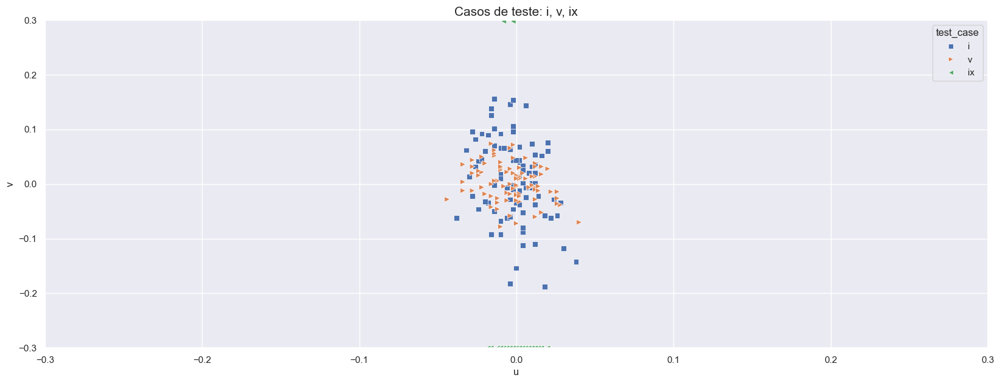

In [7]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['i','v','ix']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,ii,-0.001591,0.005295,0.015433,0.075693
1,vi,-0.002864,0.002523,0.016074,0.033129
2,x,0.001659,-0.279614,0.007786,0.109137


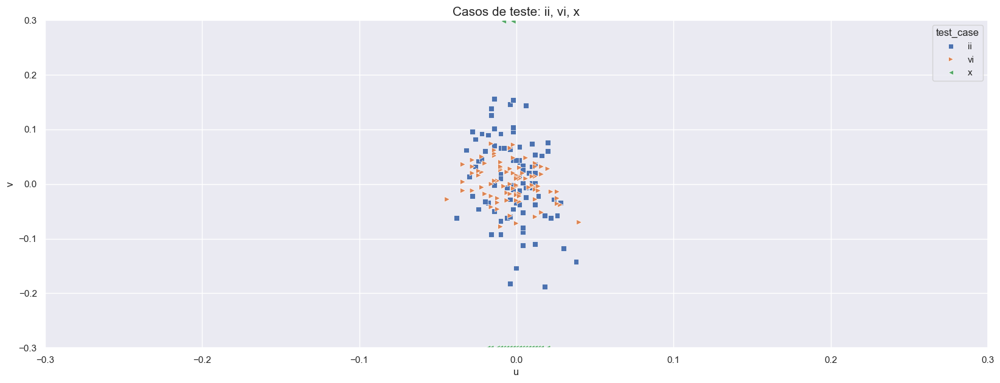

In [8]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['ii','vi','x']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,iii,-0.001341,0.002977,0.014475,0.036435
1,vii,-0.002727,0.001727,0.015433,0.023864
2,xi,0.001477,-0.259227,0.007166,0.151594


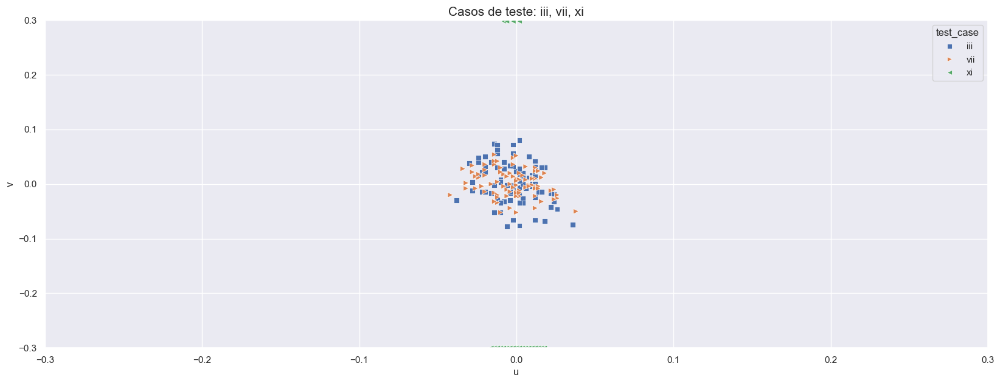

In [9]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['iii','vii','xi']
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1680: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


,test_case,u_mean,v_mean,u_std,v_std
0,iv,-0.001341,0.002977,0.014475,0.036435
1,viii,-0.002727,0.001727,0.015433,0.023864
2,xii,0.001477,-0.259227,0.007166,0.151594


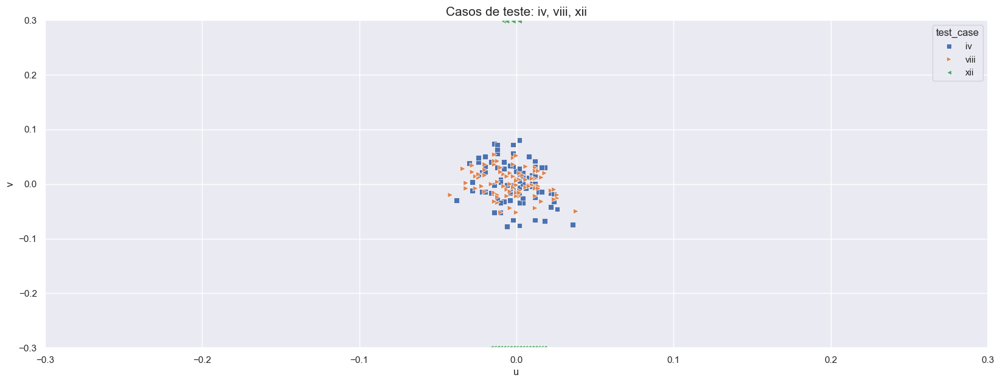

In [10]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_contours(
    parser=parser,
    test_cases=['iv','viii','xii']
)

## 2.2. Coeficientes MMSE estimados

### Mesmo modelo

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,i,0.979000,0.002095,-0.003969,1.013763,0.024697,0.089853,0.080326,0.026204
1,ii,0.979229,-0.010456,0.008128,1.013951,0.024616,0.089119,0.080437,0.026418
2,iii,0.982556,0.001170,-0.003528,1.018646,0.022678,0.042316,0.035415,0.024055
3,iv,0.983461,-0.002593,0.000462,1.016676,0.022706,0.043122,0.036274,0.024223


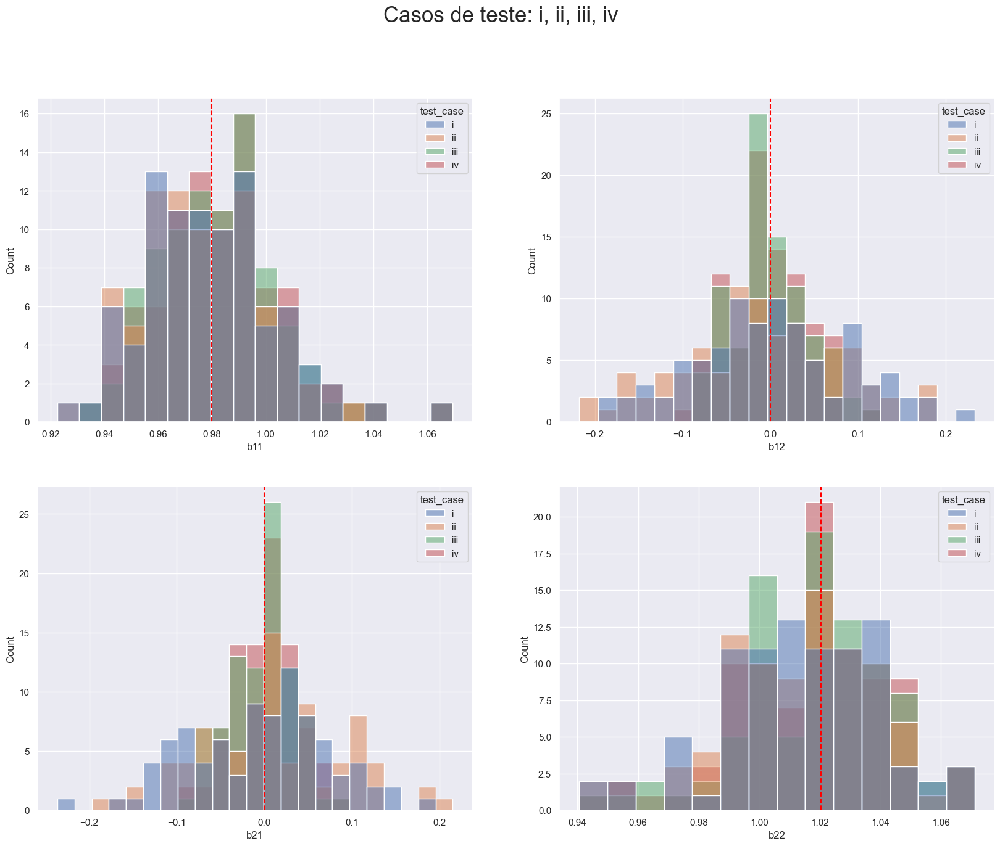

In [11]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['i','ii','iii','iv'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,v,0.889842,-0.000849,-0.003873,0.921212,0.022139,0.077174,0.069483,0.023658
1,vi,0.889661,-0.015271,0.009993,0.921658,0.022546,0.073245,0.064329,0.023538
2,vii,0.897024,-0.003128,-0.000854,0.929464,0.021430,0.040092,0.033087,0.022452
3,viii,0.897825,-0.007205,0.003839,0.930322,0.021252,0.039559,0.034237,0.022053


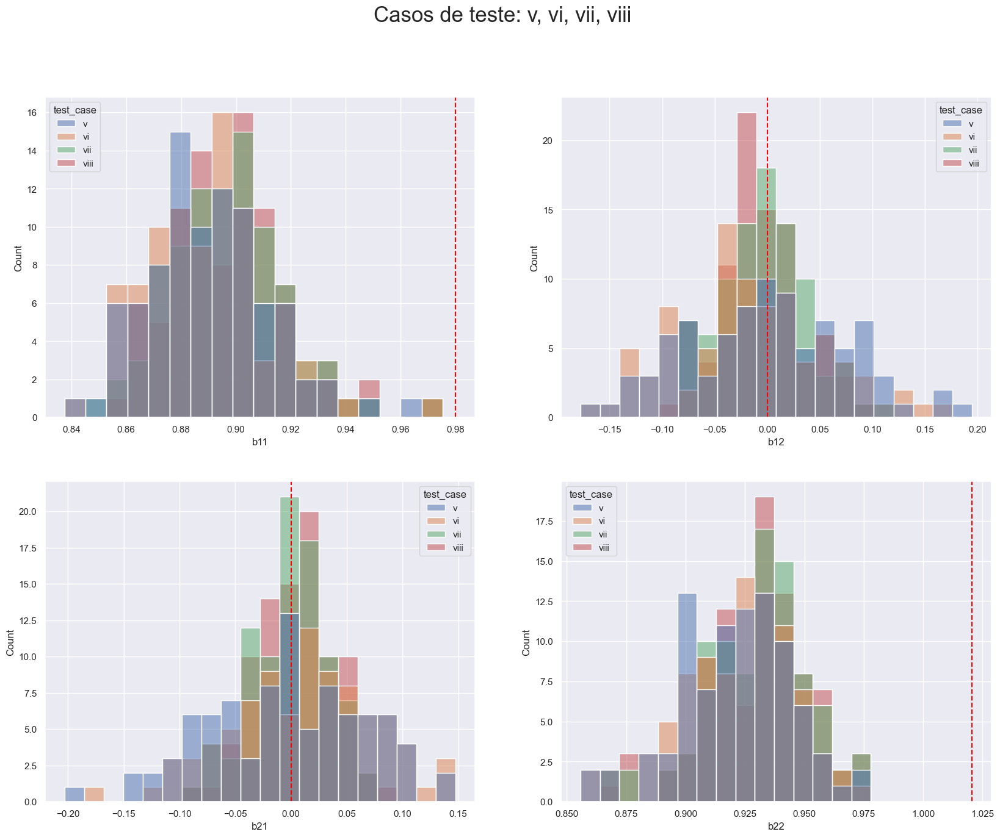

In [12]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['v','vi','vii','viii'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,ix,1.475373,1.464854,-1.412859,1.537972,0.168257,0.315466,0.311085,0.163112
1,x,1.495830,1.170830,-1.130745,1.561016,0.140047,0.922663,0.890551,0.129839
2,xi,1.834998,-0.003001,-0.004362,1.895030,0.027142,0.055323,0.049281,0.026918
3,xii,1.835466,-0.031141,0.023536,1.889193,0.026811,0.050408,0.041534,0.026158


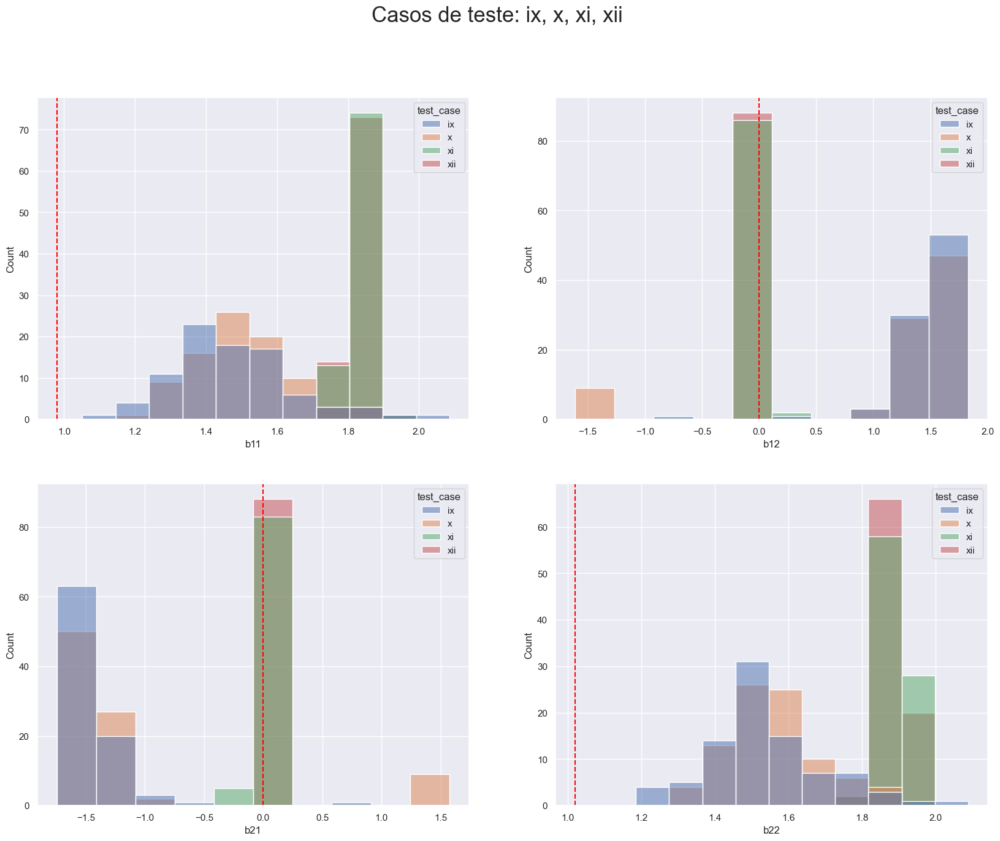

In [13]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['ix','x','xi','xii'],
    B_true=parser.execution_config['general']['B']
)

### Mesma prior

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,i,0.979000,0.002095,-0.003969,1.013763,0.024697,0.089853,0.080326,0.026204
1,ix,1.475373,1.464854,-1.412859,1.537972,0.168257,0.315466,0.311085,0.163112
2,v,0.889842,-0.000849,-0.003873,0.921212,0.022139,0.077174,0.069483,0.023658


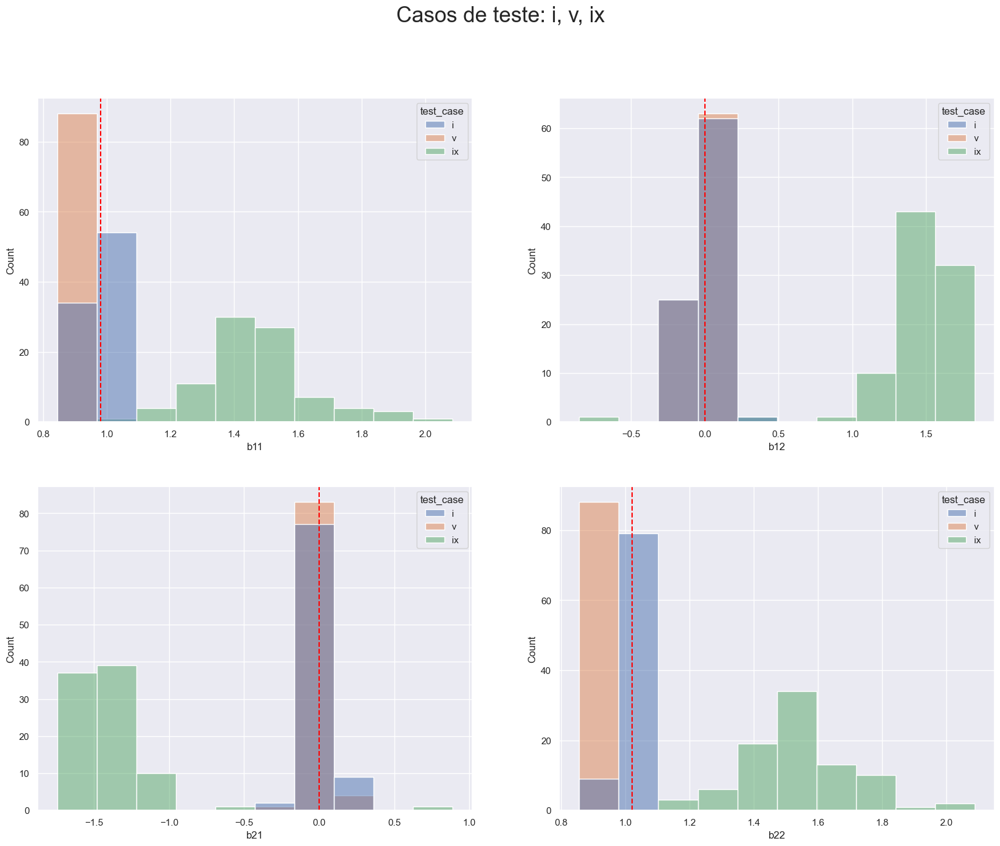

In [14]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['i','v','ix'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,ii,0.979229,-0.010456,0.008128,1.013951,0.024616,0.089119,0.080437,0.026418
1,vi,0.889661,-0.015271,0.009993,0.921658,0.022546,0.073245,0.064329,0.023538
2,x,1.495830,1.170830,-1.130745,1.561016,0.140047,0.922663,0.890551,0.129839


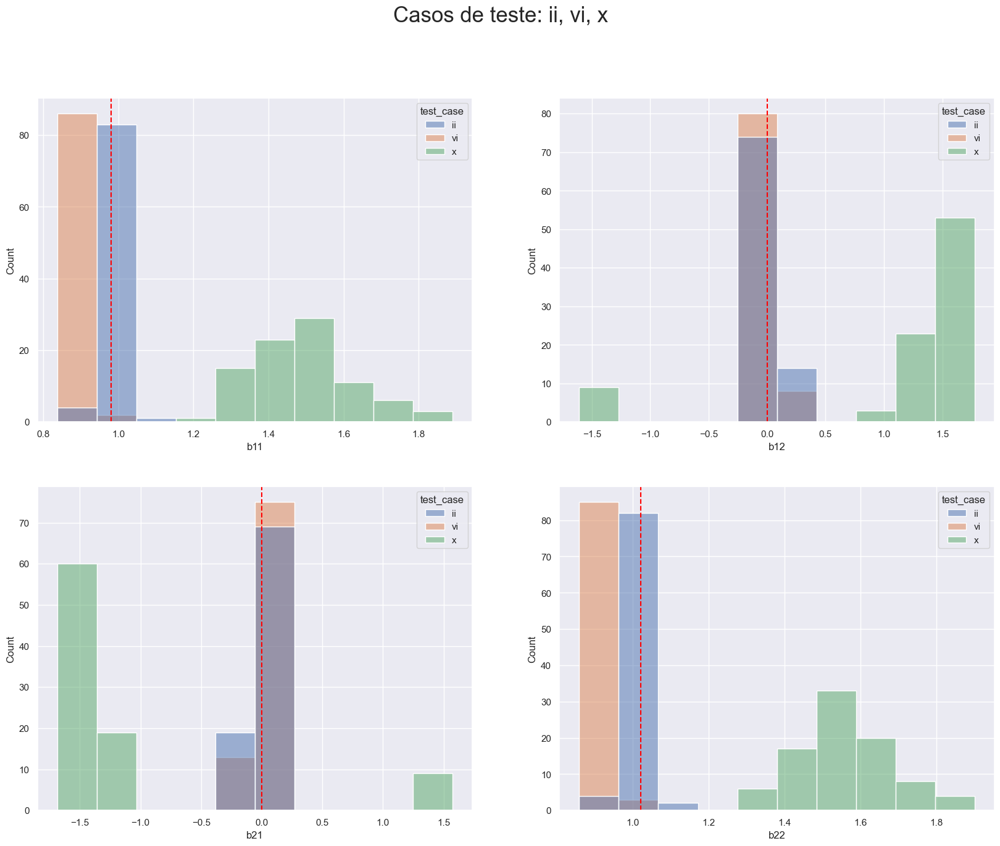

In [15]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['ii','vi','x'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,iii,0.982556,0.001170,-0.003528,1.018646,0.022678,0.042316,0.035415,0.024055
1,vii,0.897024,-0.003128,-0.000854,0.929464,0.021430,0.040092,0.033087,0.022452
2,xi,1.834998,-0.003001,-0.004362,1.895030,0.027142,0.055323,0.049281,0.026918


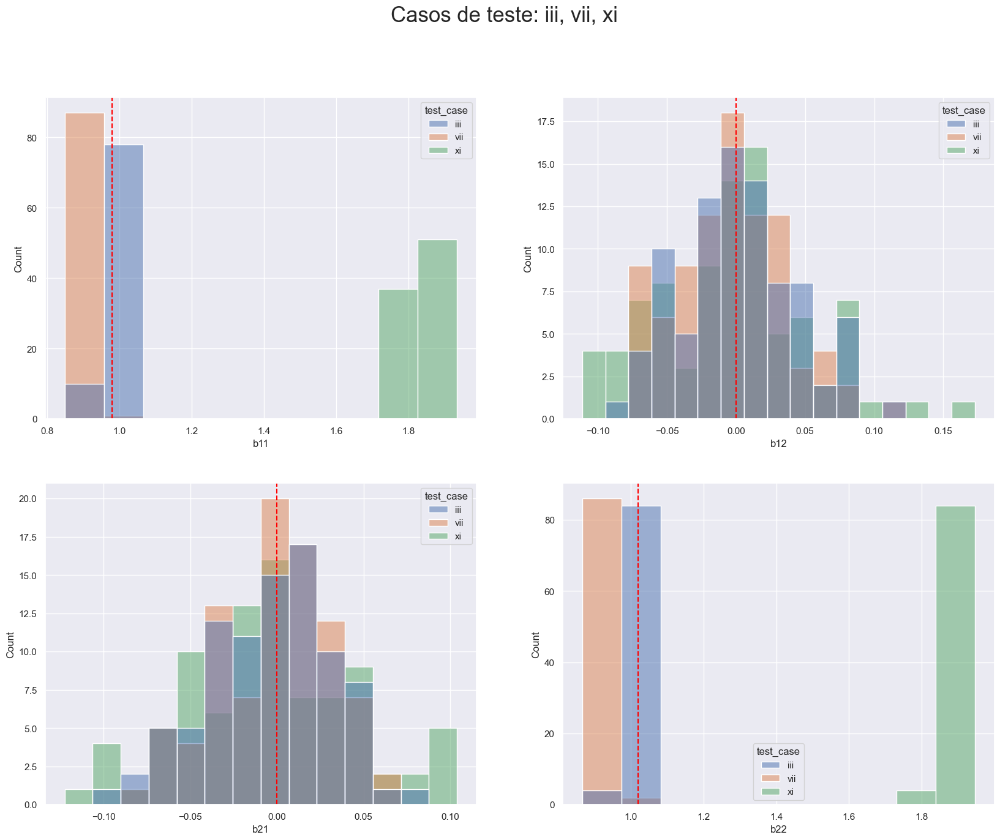

In [16]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['iii','vii','xi'],
    B_true=parser.execution_config['general']['B']
)

,test_case,b11_mean,b12_mean,b21_mean,b22_mean,b11_std,b12_std,b21_std,b22_std
0,iv,0.983461,-0.002593,0.000462,1.016676,0.022706,0.043122,0.036274,0.024223
1,viii,0.897825,-0.007205,0.003839,0.930322,0.021252,0.039559,0.034237,0.022053
2,xii,1.835466,-0.031141,0.023536,1.889193,0.026811,0.050408,0.041534,0.026158


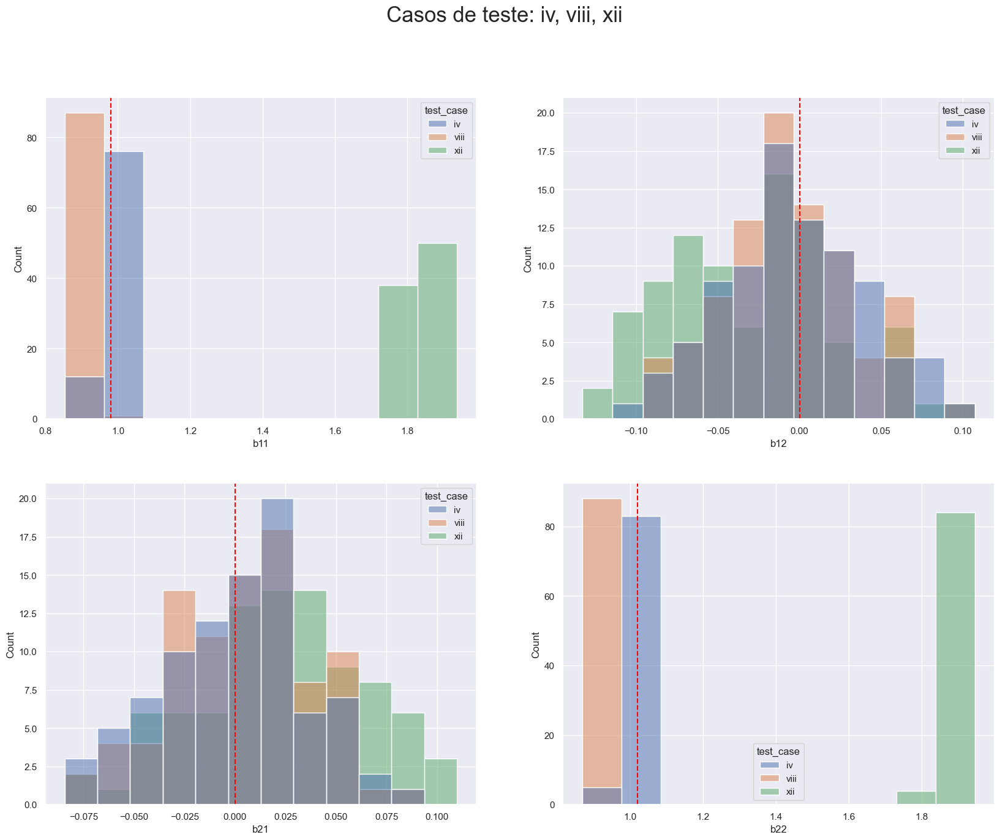

In [17]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################
EstimationGraphPlotter.plot_test_cases_mmse_coefficient_estimates(
    parser=parser,
    test_cases=['iv','viii','xii'],
    B_true=parser.execution_config['general']['B']
)

## 2.3. Erros MMSE

### Mesmo modelo

,test_case,errors_mean,errors_min,errors_max,errors_std
0,i,0.076170,0.010400,0.235363,0.045488
1,ii,0.075202,0.005268,0.219372,0.047344
2,iii,0.041136,0.007770,0.090780,0.019169
3,iv,0.041933,0.004052,0.087285,0.019367


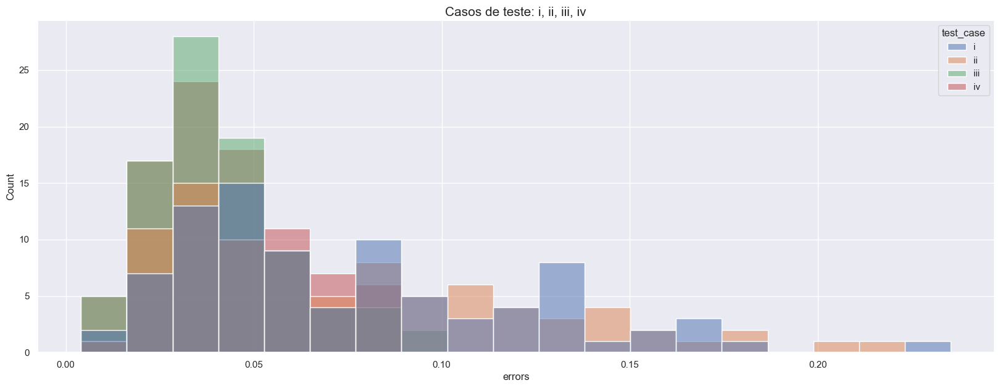

In [18]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['i','ii','iii','iv']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,v,0.118531,0.069994,0.224573,0.028085
1,vi,0.116557,0.070785,0.203431,0.027514
2,vii,0.095784,0.064340,0.125807,0.014672
3,viii,0.095229,0.064941,0.124110,0.014504


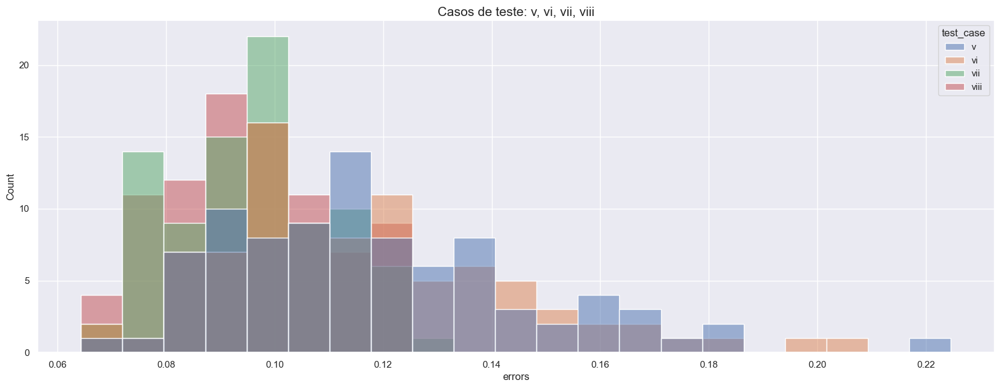

In [19]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,ix,1.561542,1.172670,1.778643,0.107289
1,x,1.557508,1.346865,1.745455,0.083801
2,xi,0.866302,0.816055,0.912309,0.018837
3,xii,0.863679,0.823509,0.907598,0.017912


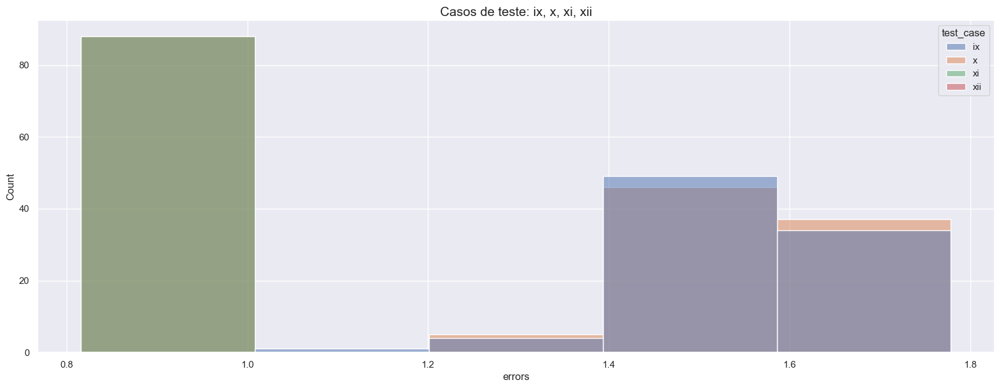

In [20]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

,test_case,errors_mean,errors_min,errors_max,errors_std
0,i,0.076170,0.010400,0.235363,0.045488
1,ix,1.561542,1.172670,1.778643,0.107289
2,v,0.118531,0.069994,0.224573,0.028085


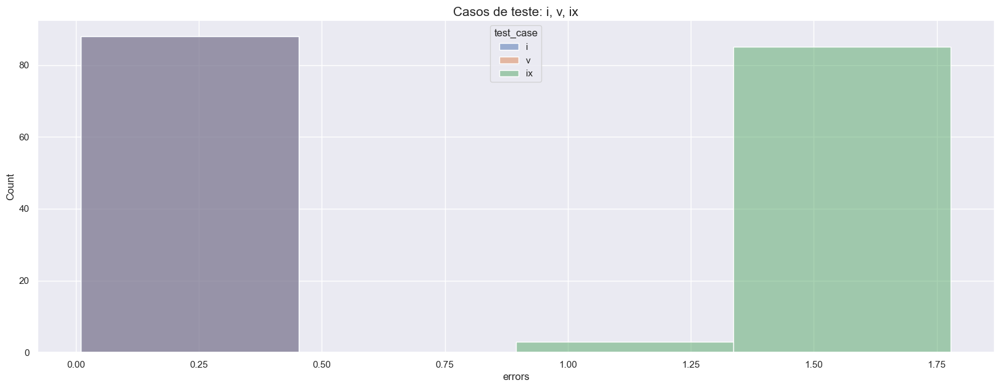

In [21]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['i','v','ix']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,ii,0.075202,0.005268,0.219372,0.047344
1,vi,0.116557,0.070785,0.203431,0.027514
2,x,1.557508,1.346865,1.745455,0.083801


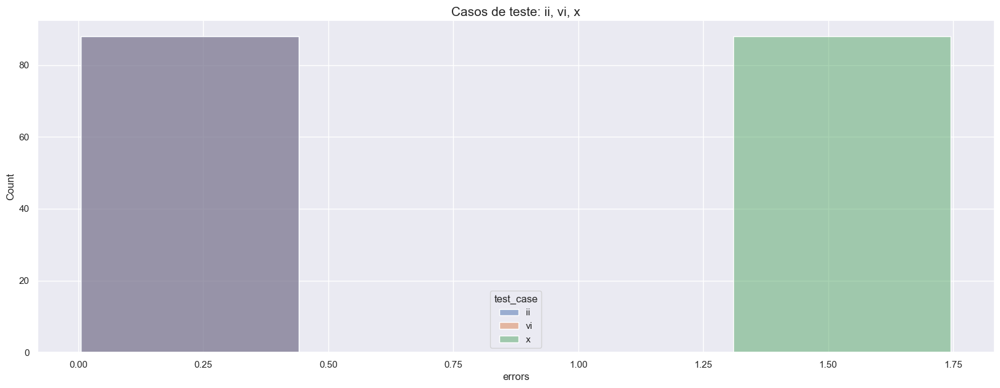

In [22]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['ii','vi','x']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,iii,0.041136,0.007770,0.090780,0.019169
1,vii,0.095784,0.064340,0.125807,0.014672
2,xi,0.866302,0.816055,0.912309,0.018837


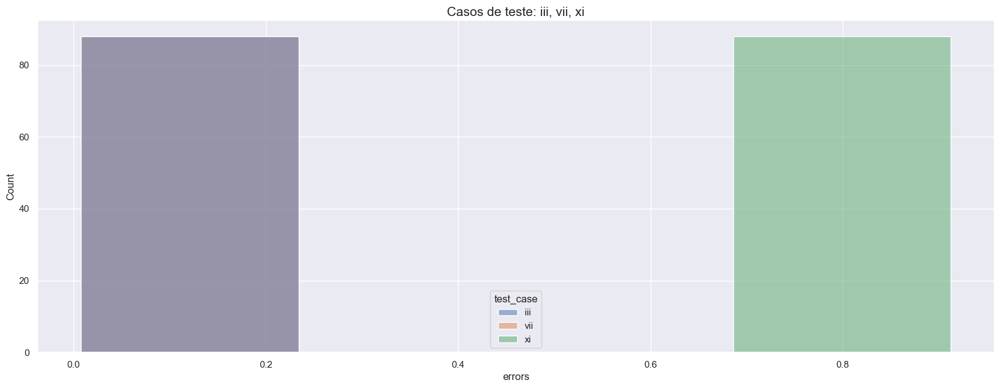

In [23]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['iii','vii','xi']
)

,test_case,errors_mean,errors_min,errors_max,errors_std
0,iv,0.041933,0.004052,0.087285,0.019367
1,viii,0.095229,0.064941,0.124110,0.014504
2,xii,0.863679,0.823509,0.907598,0.017912


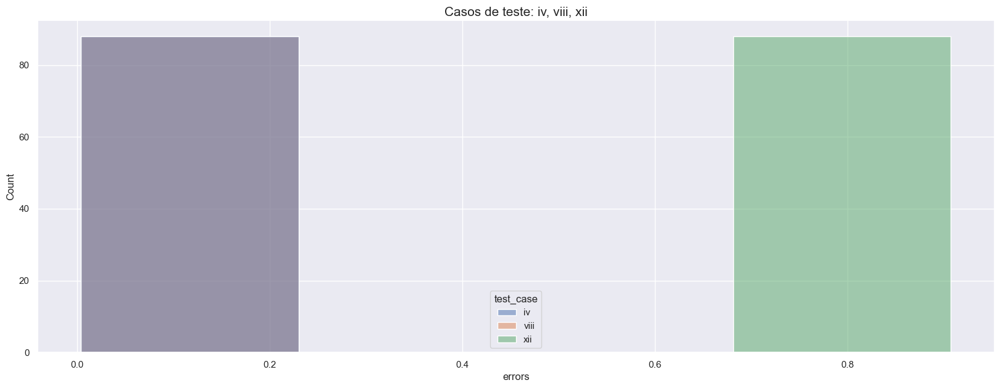

In [24]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_mmse_errors(
    parser=parser,
    test_cases=['iv','viii','xii']
)

## 2.4. Determinantes

### Mesmo modelo

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,i,0.812672,0.944441,1.183762,1.276985
1,ii,0.796264,0.954493,1.174817,1.254500
2,iii,0.827443,0.949573,1.183779,1.217730
3,iv,0.802465,0.950268,1.186002,1.223003


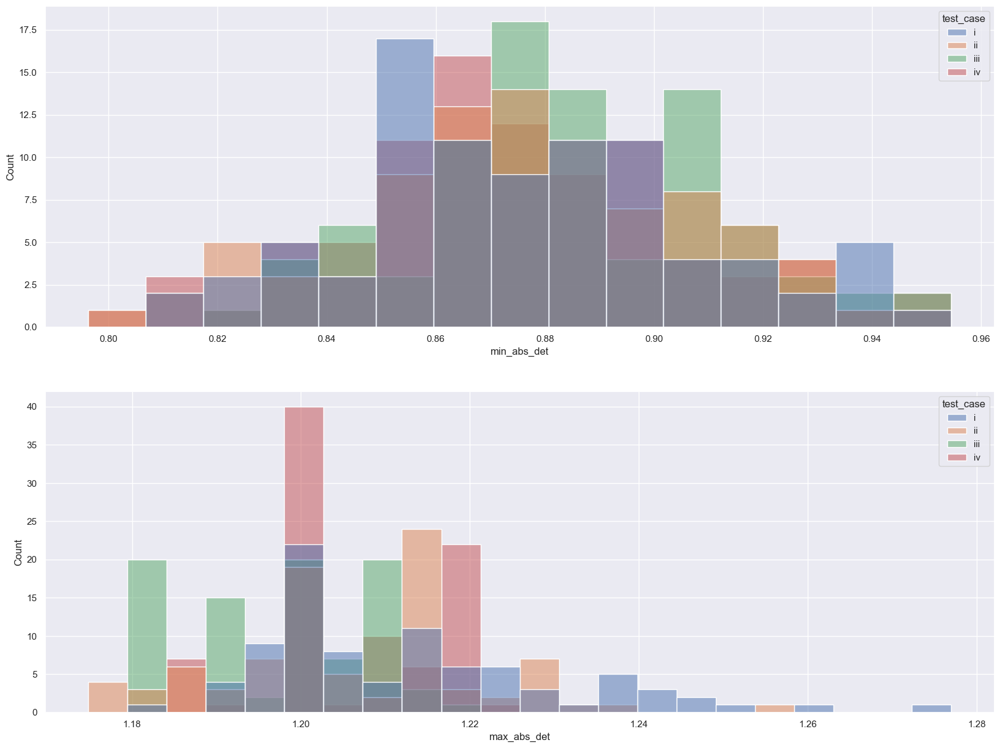

In [25]:
##########################################################
# ESPECIFICAÇÃO PERFEITA: CASOS DE TESTE i, ii, iii e iv #
##########################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['i','ii','iii','iv']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,v,0.660452,0.777080,1.186458,1.213168
1,vi,0.657271,0.777628,1.184141,1.218899
2,vii,0.674764,0.779374,1.191345,1.215873
3,viii,0.684450,0.783167,1.176481,1.207420


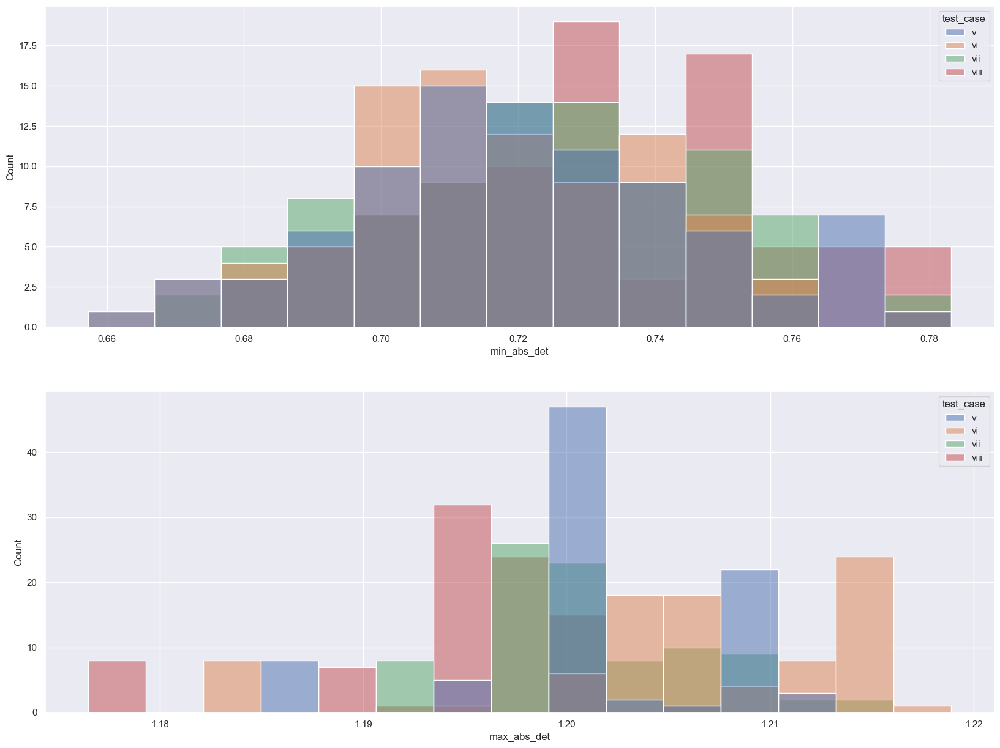

In [26]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['v','vi','vii','viii']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,ix,1.198636,1.202978,4.680761,5.374812
1,x,1.200023,1.221110,4.724401,5.561301
2,xi,1.201551,1.214334,3.684662,4.134947
3,xii,1.198958,1.211172,3.704581,4.097560


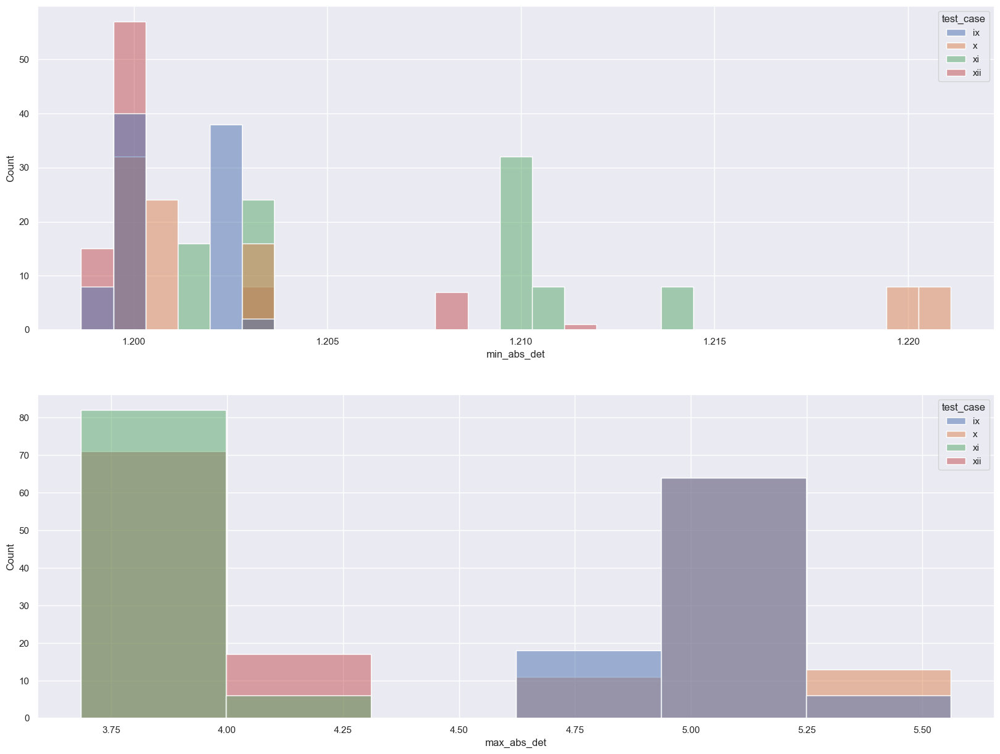

In [27]:
#################################################################
# ESPECIFICAÇÃO MUITO INCORRETA: CASOS DE TESTE ix, x, xi e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['ix','x','xi','xii']
)

### Mesma prior

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,i,0.812672,0.944441,1.183762,1.276985
1,ix,1.198636,1.202978,4.680761,5.374812
2,v,0.660452,0.777080,1.186458,1.213168


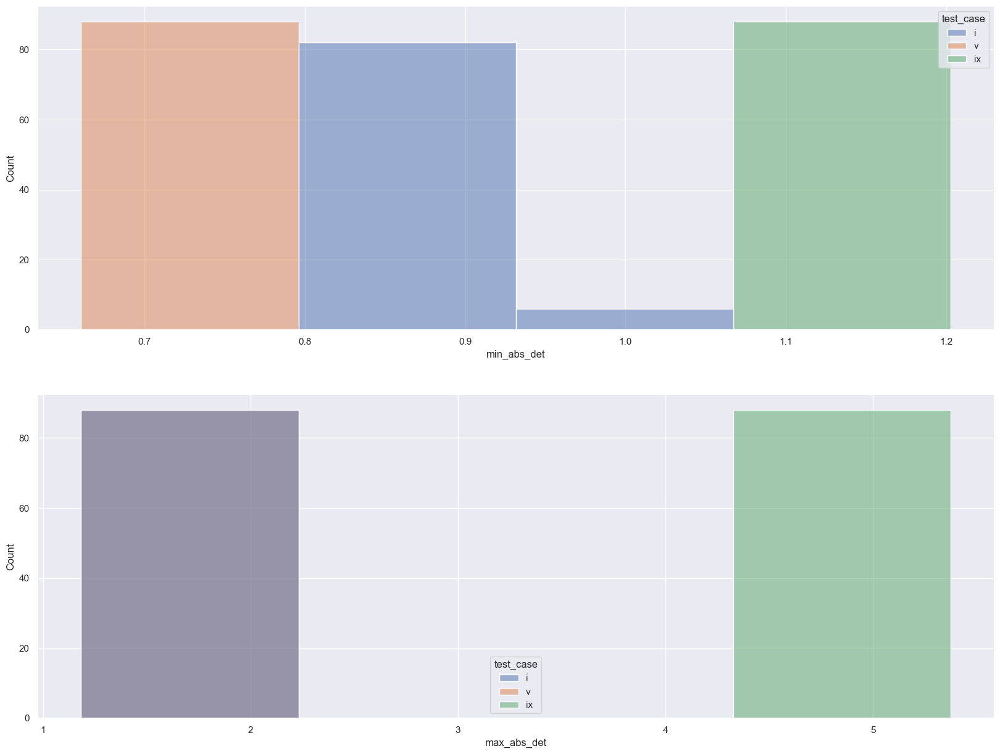

In [28]:
#############################################
# PRIOR UNIFORME: CASOS DE TESTE i, v, e ix #
#############################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['i','v','ix']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,ii,0.796264,0.954493,1.174817,1.254500
1,vi,0.657271,0.777628,1.184141,1.218899
2,x,1.200023,1.221110,4.724401,5.561301


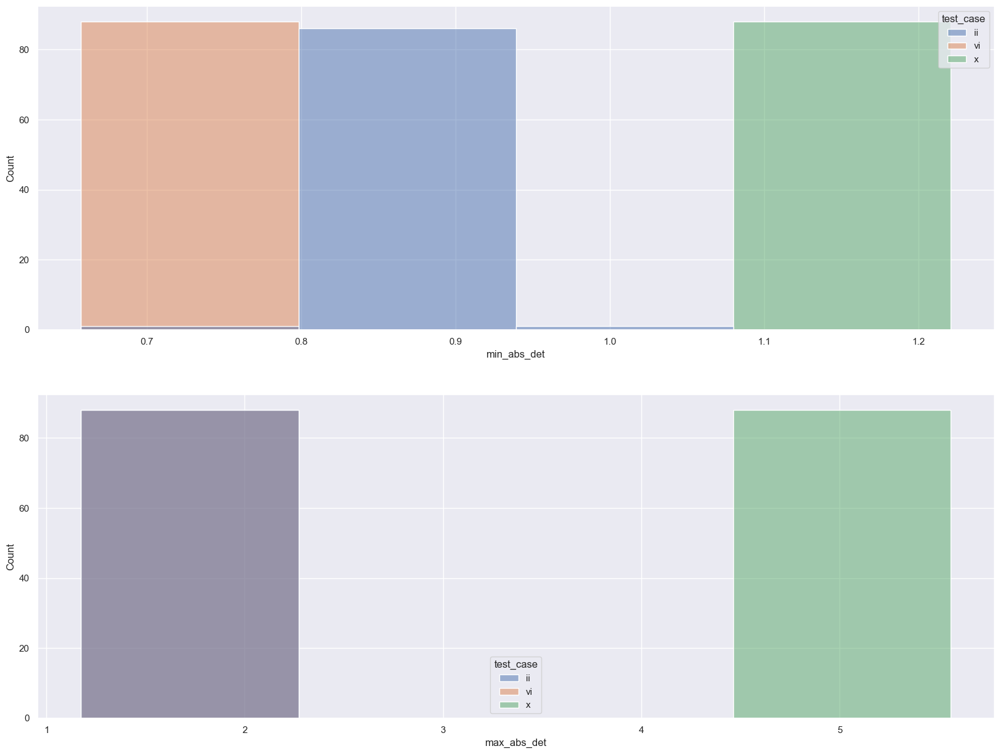

In [29]:
#################################################################
# PRIOR CORRETA E POUCO INFORMATIVA: CASOS DE TESTE ii, vi, e x #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['ii','vi','x']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,iii,0.827443,0.949573,1.183779,1.217730
1,vii,0.674764,0.779374,1.191345,1.215873
2,xi,1.201551,1.214334,3.684662,4.134947


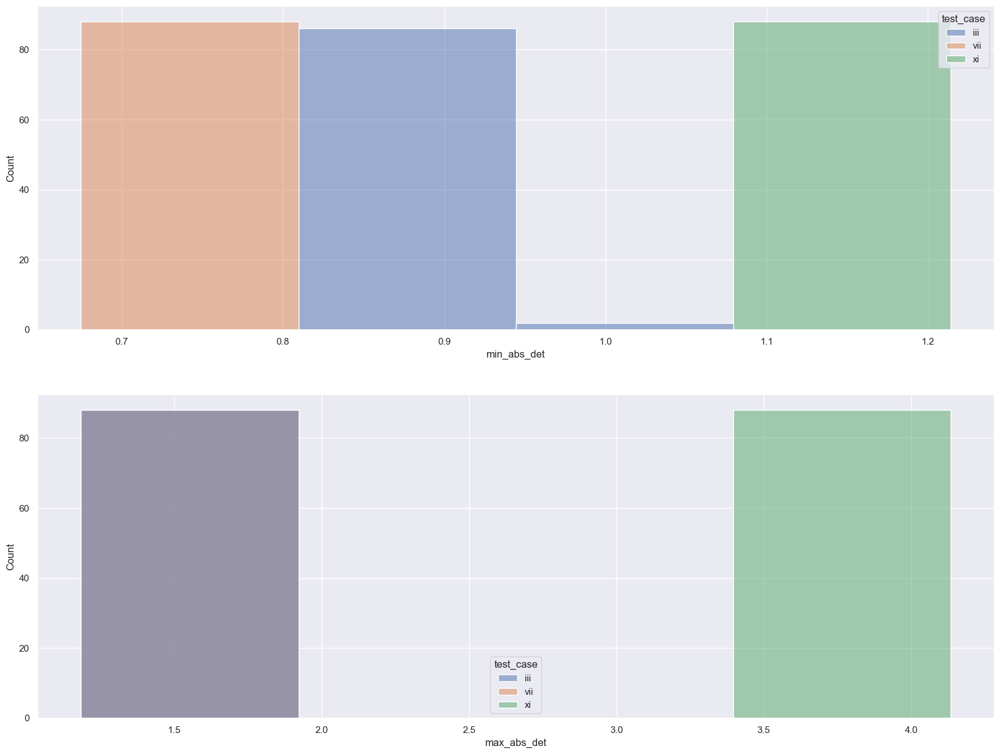

In [30]:
##############################################################
# PRIOR CORRETA E INFORMATIVA: CASOS DE TESTE iii, vii, e xi #
##############################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['iii','vii','xi']
)

,test_case,min_abs_det_min,min_abs_det_max,max_abs_det_min,max_abs_det_max
0,iv,0.802465,0.950268,1.186002,1.223003
1,viii,0.684450,0.783167,1.176481,1.207420
2,xii,1.198958,1.211172,3.704581,4.097560


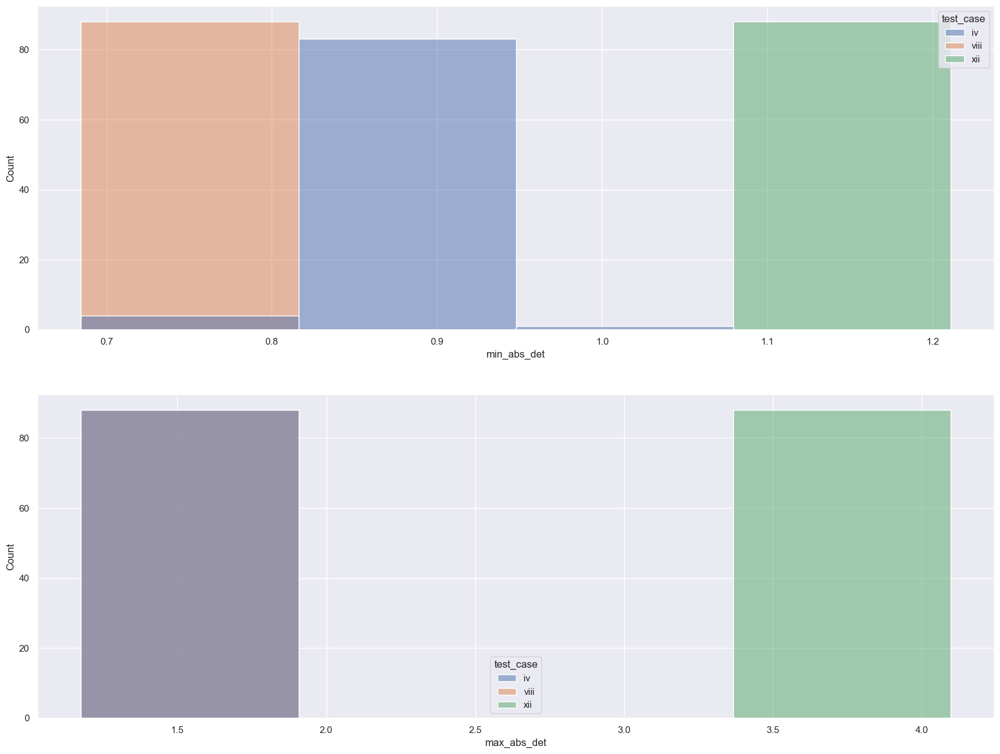

In [31]:
#################################################################
# PRIOR INCORRETA E INFORMATIVA: CASOS DE TESTE iv, viii, e xii #
#################################################################

EstimationGraphPlotter.plot_test_cases_min_determinants(
    parser=parser,
    test_cases=['iv','viii','xii']
)

### Todos os casos de teste - scatterplots

/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:2095: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(


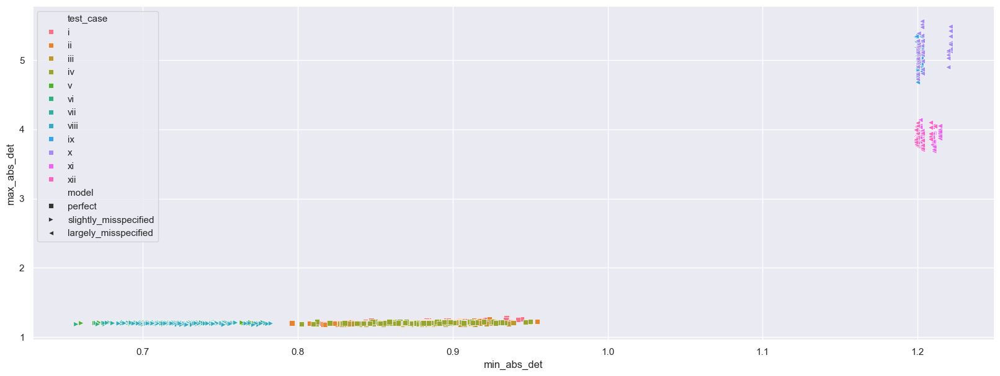

In [32]:
####################################
# MARKERS IGUAIS PARA MESMO MODELO #
####################################

EstimationGraphPlotter.plot_test_cases_determinants_scatter(
    parser,
    marker='model'
)

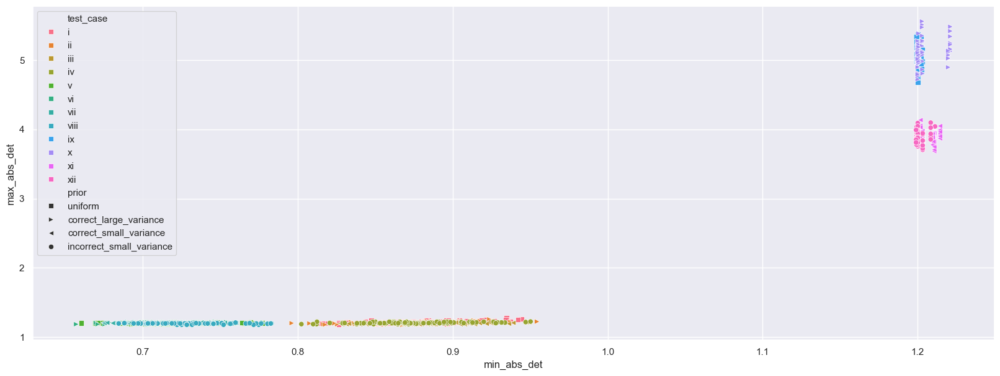

In [33]:
###################################
# MARKERS IGUAIS PARA MESMA PRIOR #
###################################

EstimationGraphPlotter.plot_test_cases_determinants_scatter(
    parser,
    marker='prior'
)

# 3. Análises - casos de teste individuais    

## i.

In [34]:
test_case='i'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


/Users/leonardo.tessarolo/git/bayesian_bss/src/utilities.py:1575: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


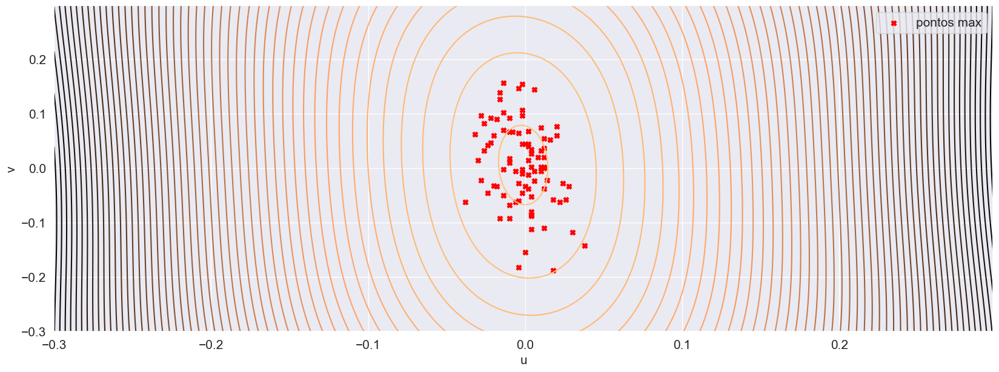

In [35]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


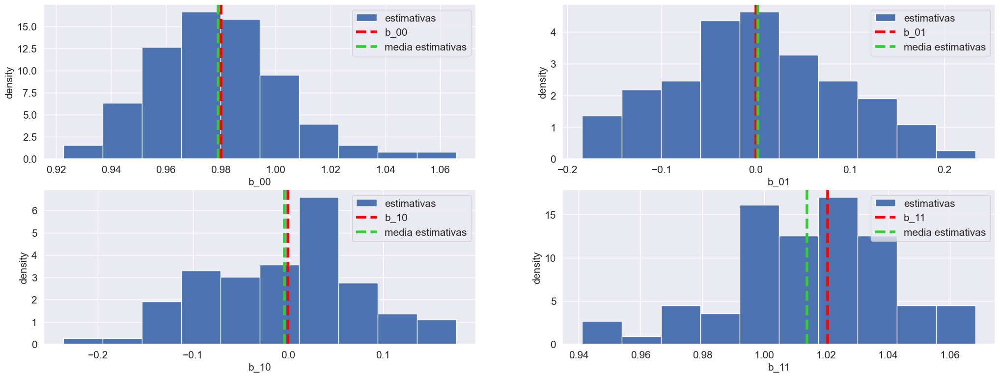

In [36]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.08
Max error: 0.24
Min error: 0.01
####################################################################################################


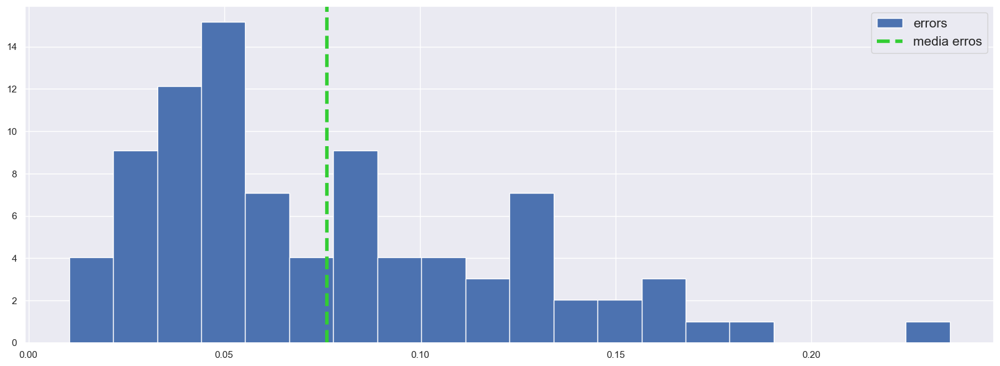

In [37]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


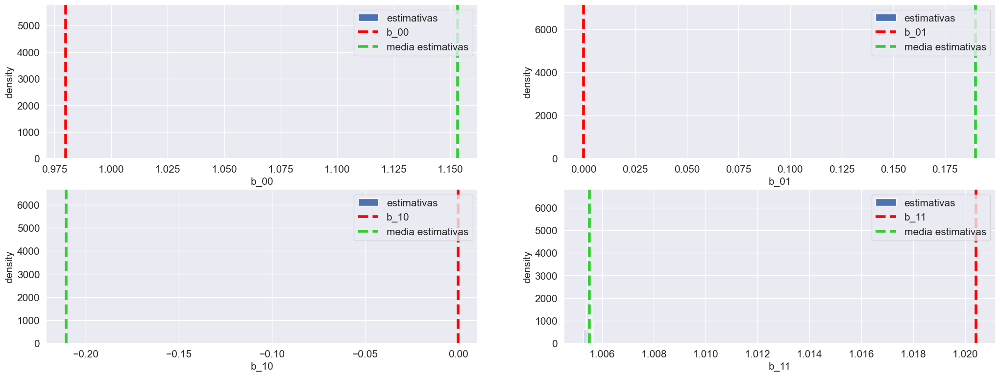

In [38]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.23
####################################################################################################


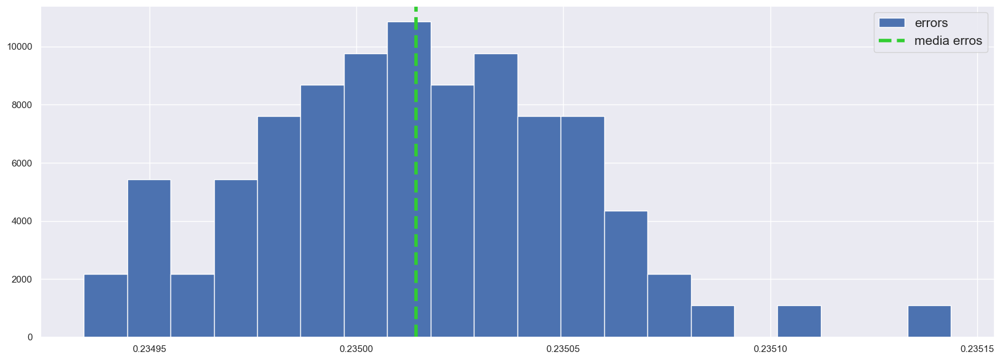

In [39]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## ii.

In [40]:
test_case='ii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


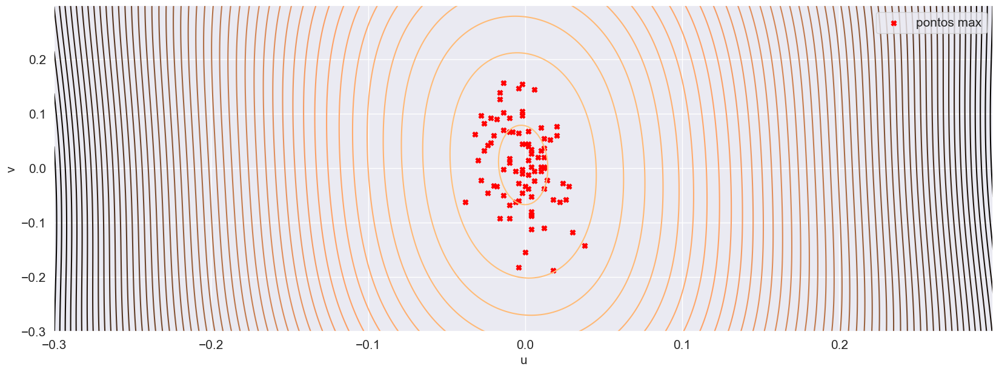

In [41]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


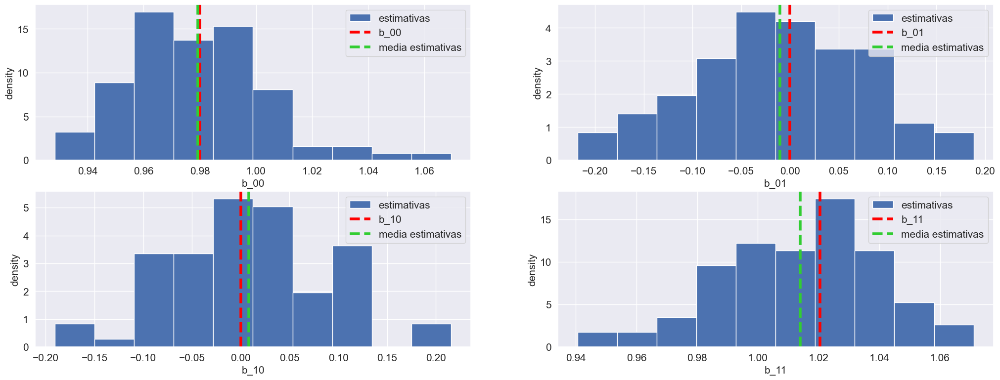

In [42]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.08
Max error: 0.22
Min error: 0.01
####################################################################################################


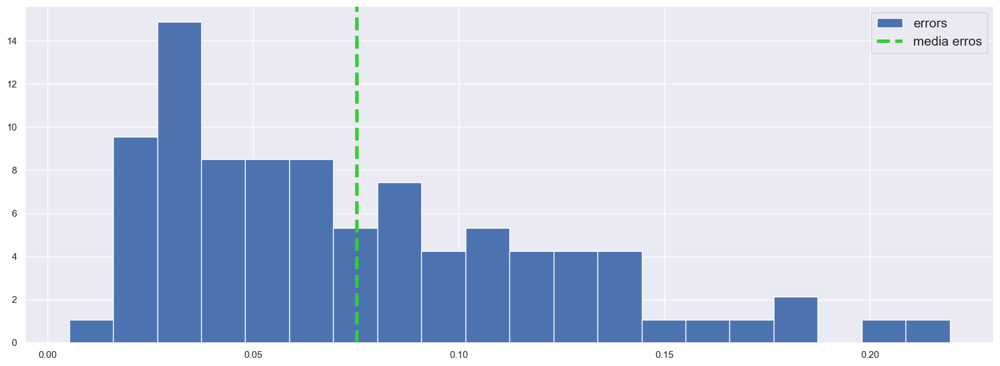

In [43]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


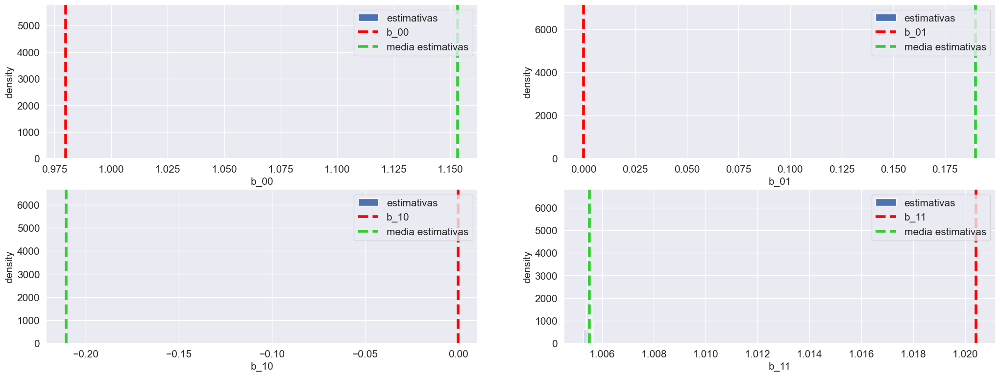

In [44]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.23
####################################################################################################


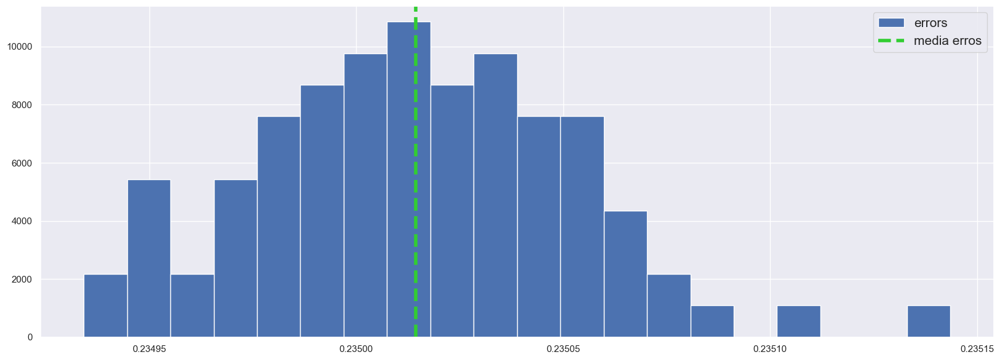

In [45]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## iii.

In [46]:
test_case='iii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


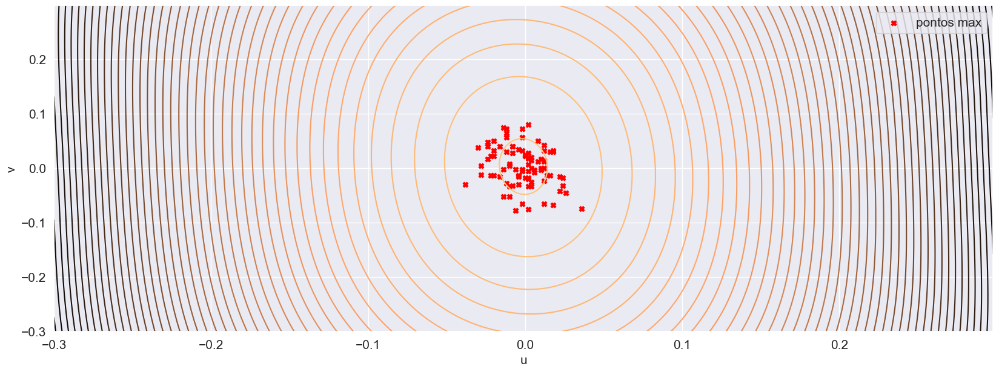

In [47]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


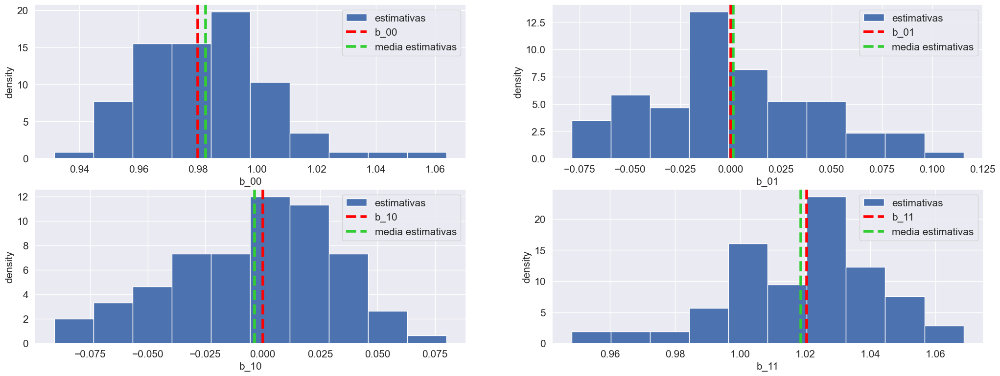

In [48]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.04
Max error: 0.09
Min error: 0.01
####################################################################################################


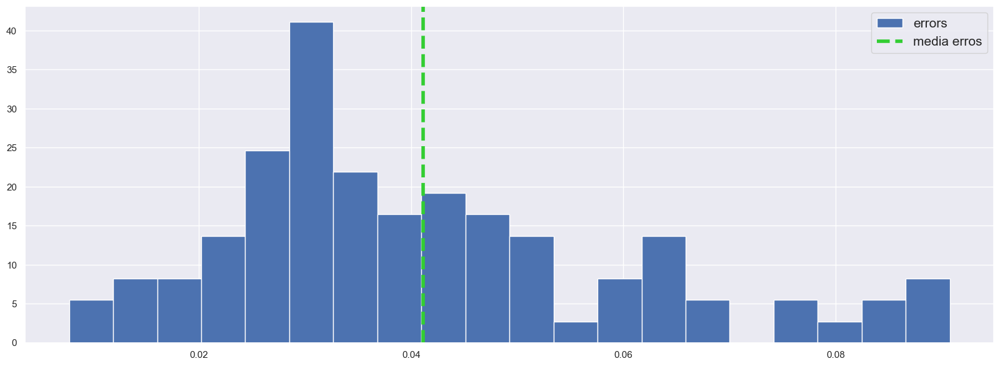

In [49]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


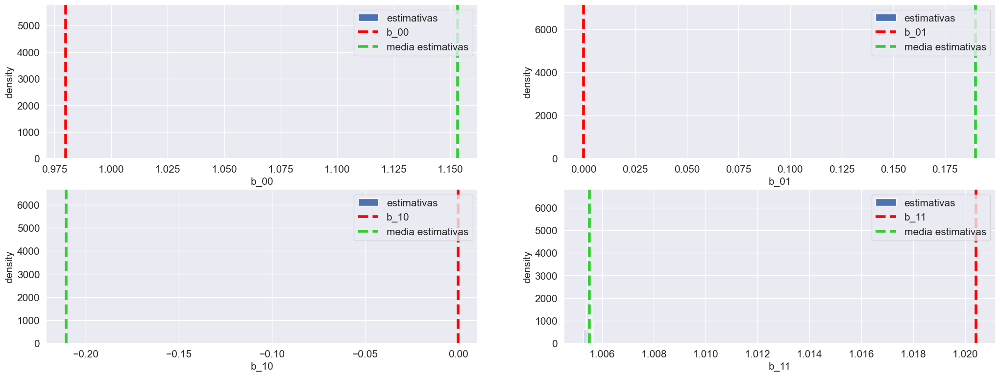

In [50]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.23
####################################################################################################


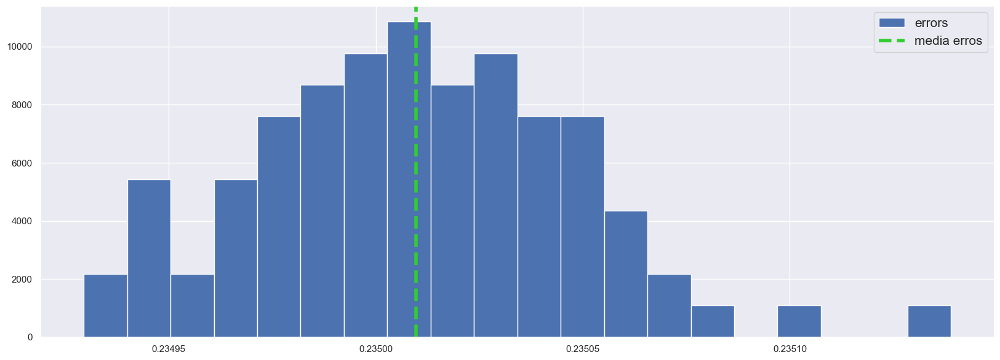

In [51]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## iv.

In [52]:
test_case='iv'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


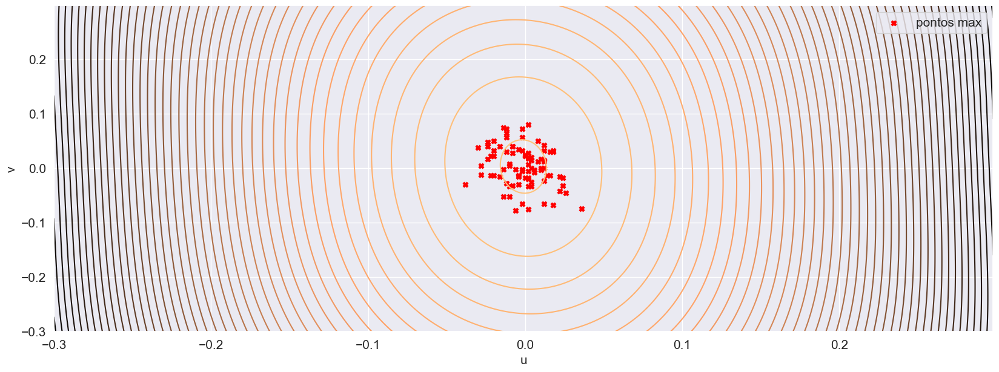

In [53]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


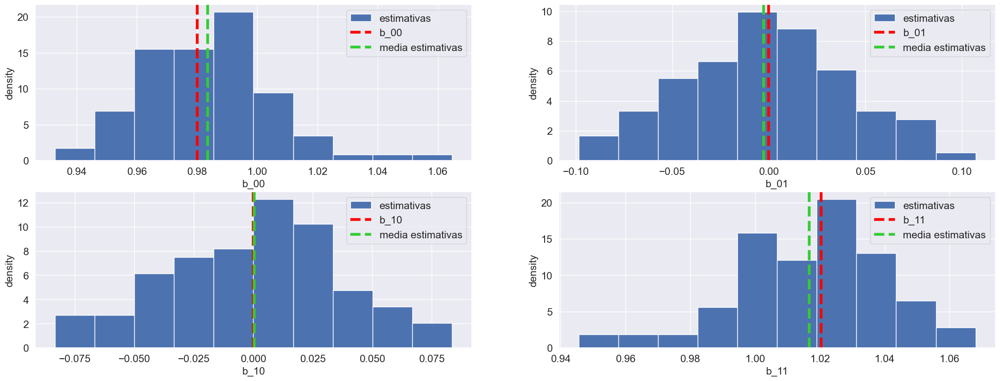

In [54]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.04
Max error: 0.09
Min error: 0.0
####################################################################################################


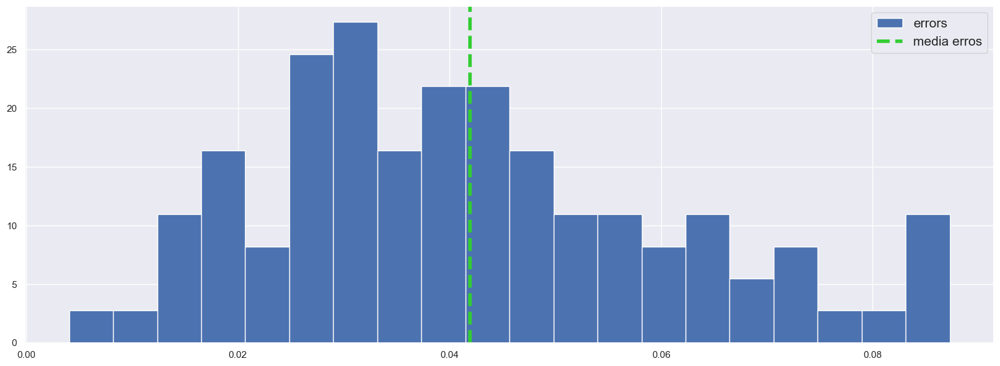

In [55]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


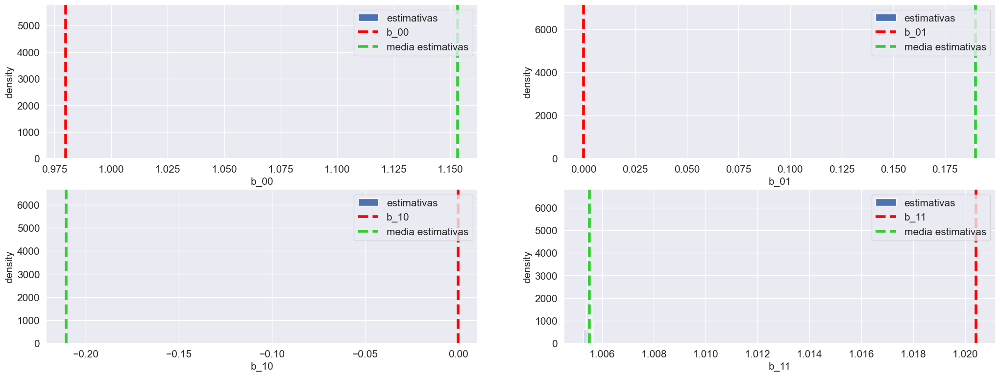

In [56]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.23
####################################################################################################


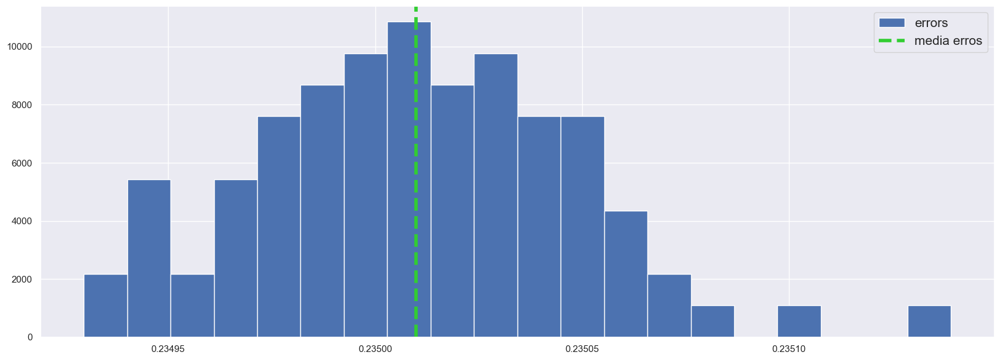

In [57]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## v.

In [58]:
test_case='v'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


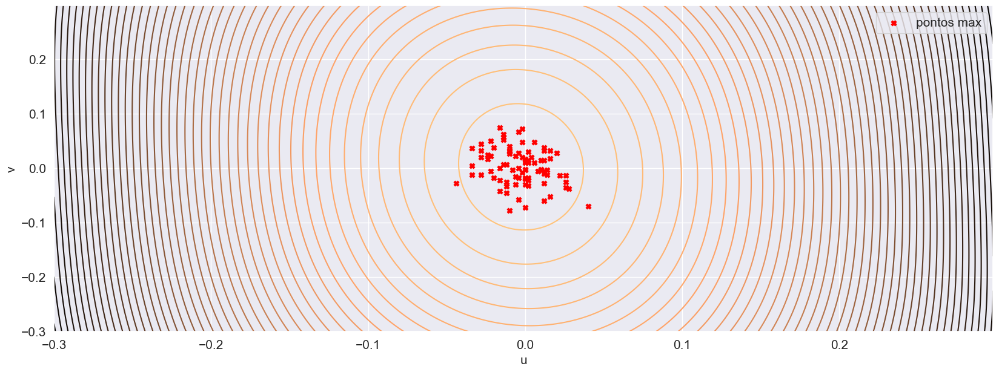

In [59]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


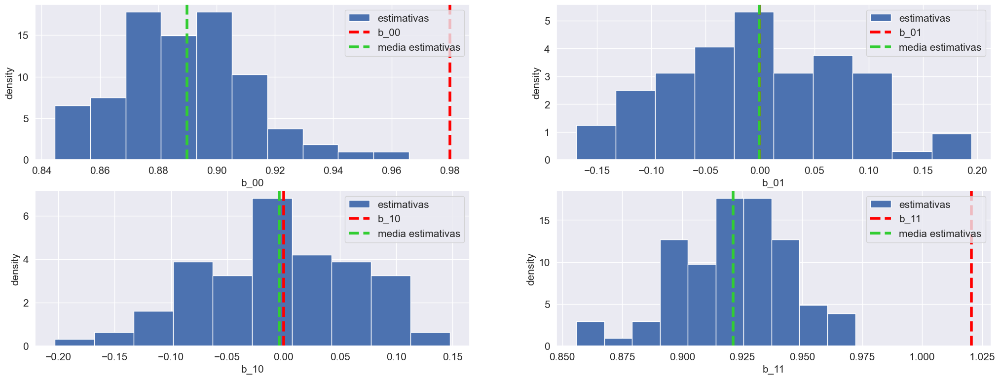

In [60]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.12
Max error: 0.22
Min error: 0.07
####################################################################################################


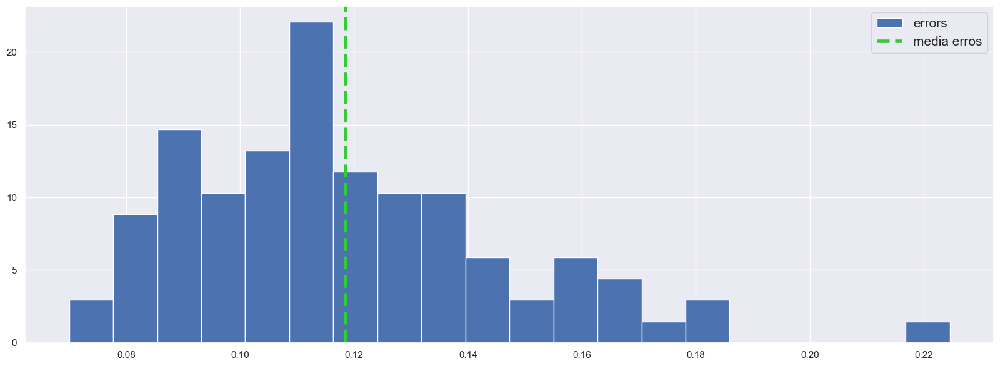

In [61]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


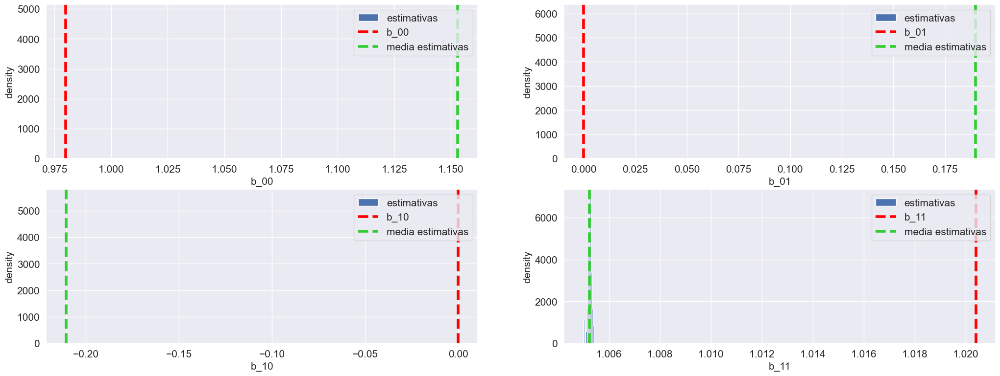

In [62]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.23
Max error: 0.24
Min error: 0.23
####################################################################################################


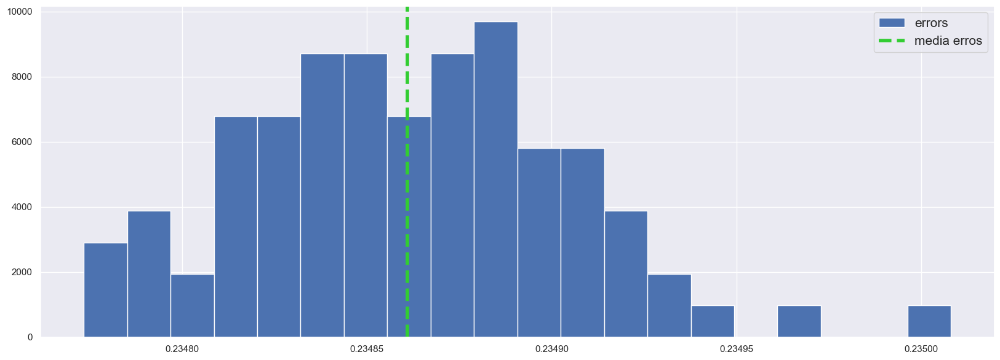

In [63]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## vii.

In [64]:
test_case='vii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


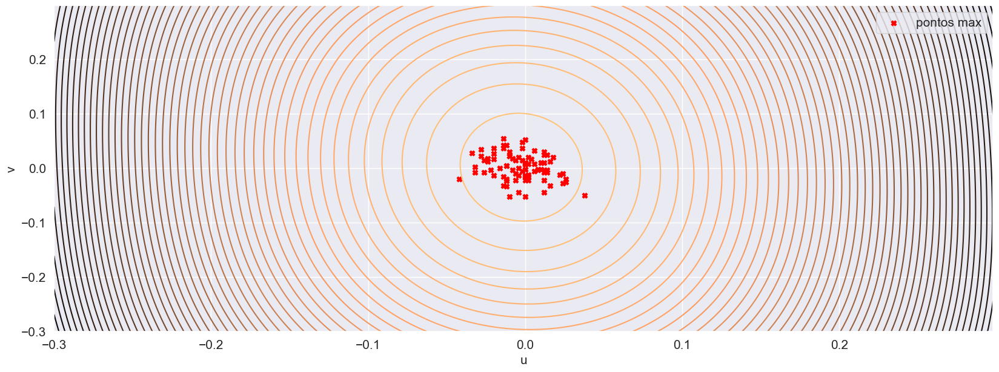

In [65]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


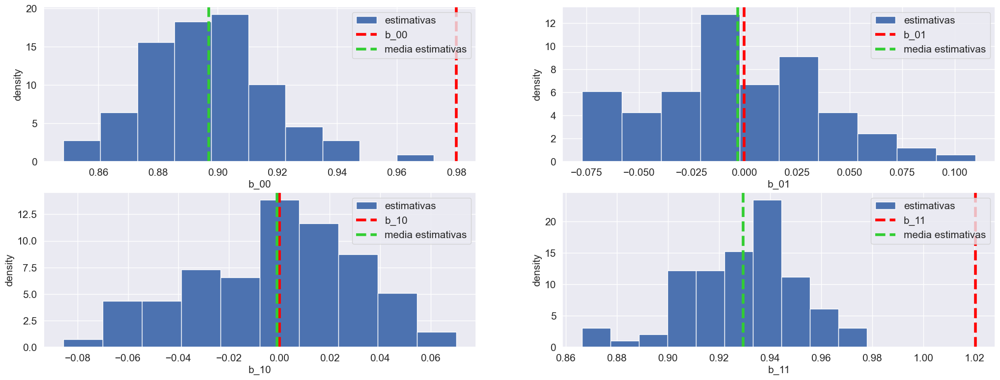

In [66]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.1
Max error: 0.13
Min error: 0.06
####################################################################################################


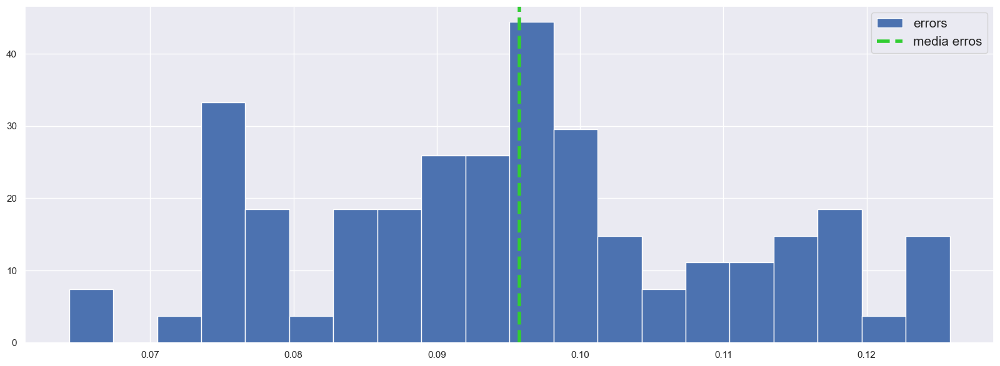

In [67]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


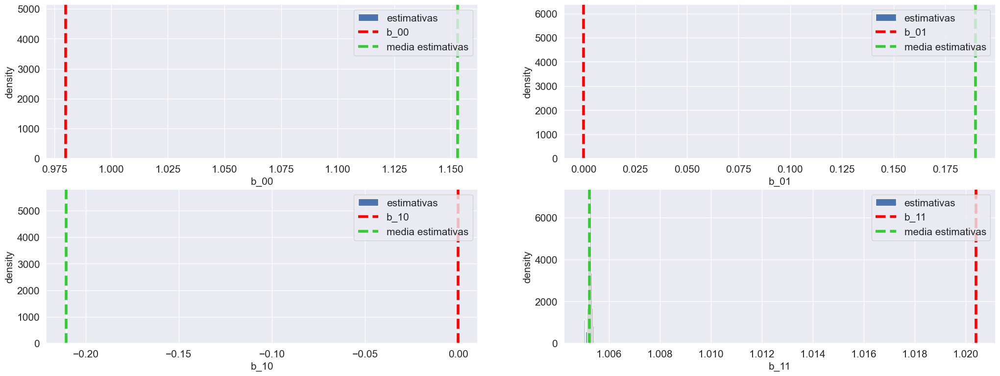

In [68]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.23
Max error: 0.24
Min error: 0.23
####################################################################################################


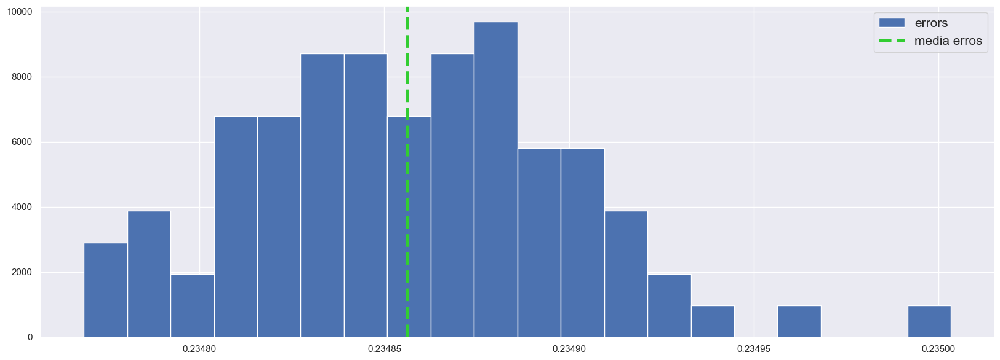

In [69]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## viii.

In [70]:
test_case='viii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


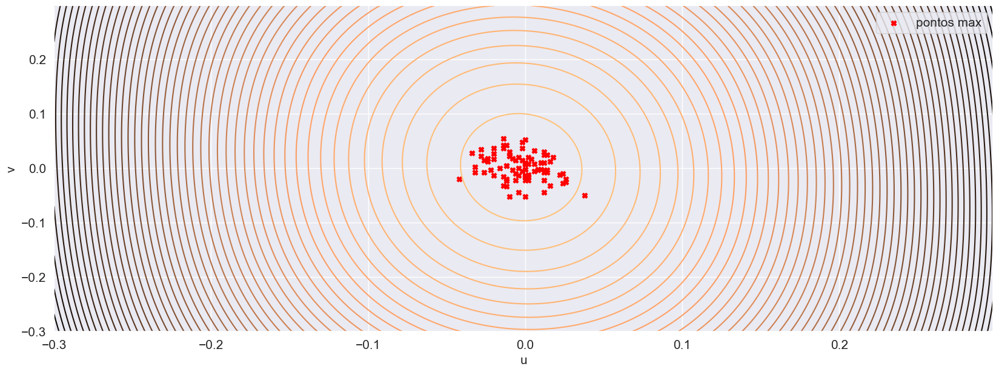

In [71]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


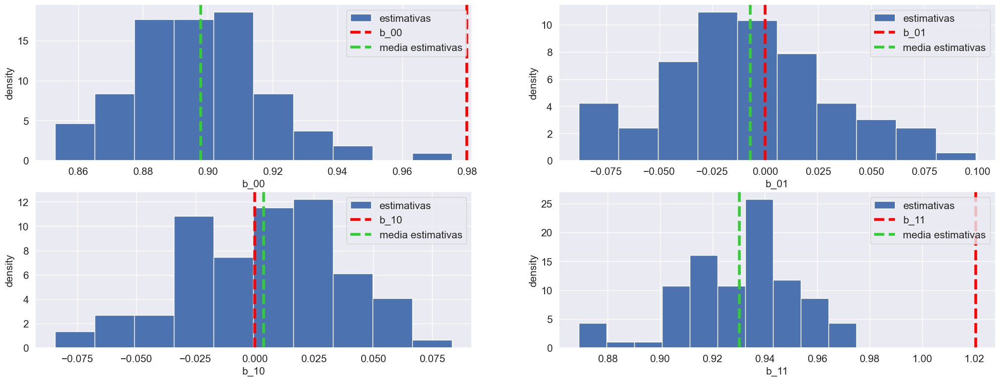

In [72]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.1
Max error: 0.12
Min error: 0.06
####################################################################################################


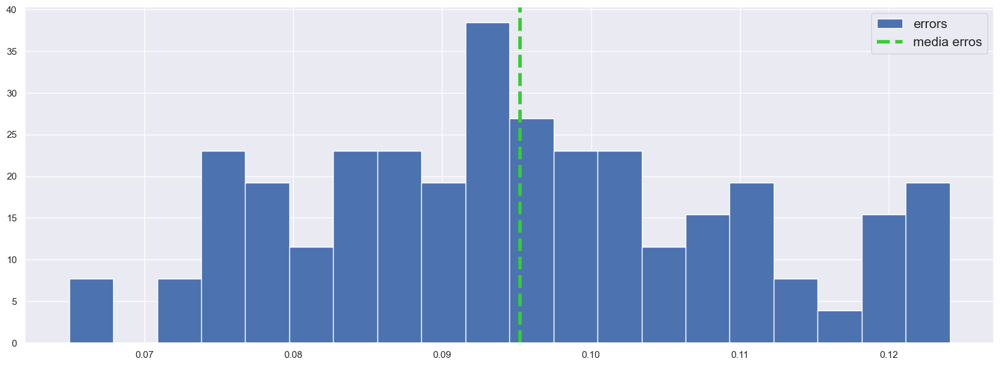

In [73]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


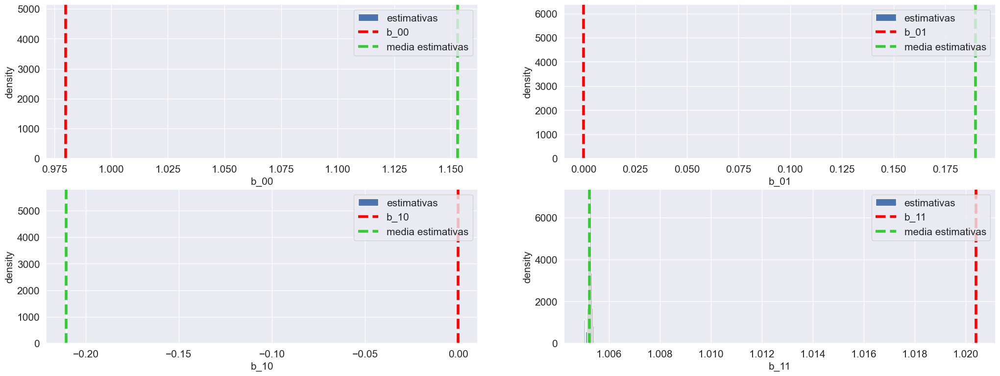

In [74]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.23
Max error: 0.24
Min error: 0.23
####################################################################################################


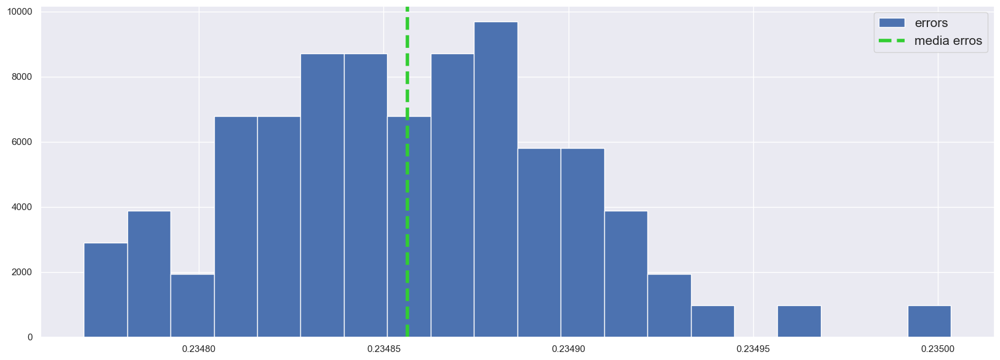

In [75]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## ix.

In [76]:
test_case='ix'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


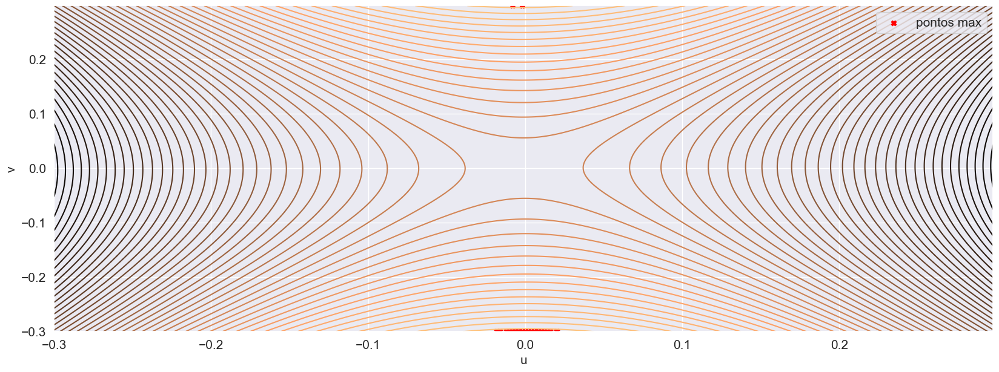

In [77]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


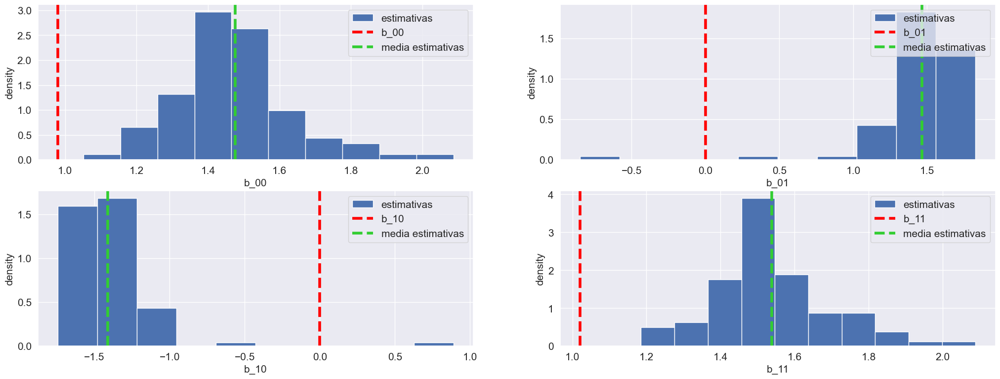

In [78]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 1.56
Max error: 1.78
Min error: 1.17
####################################################################################################


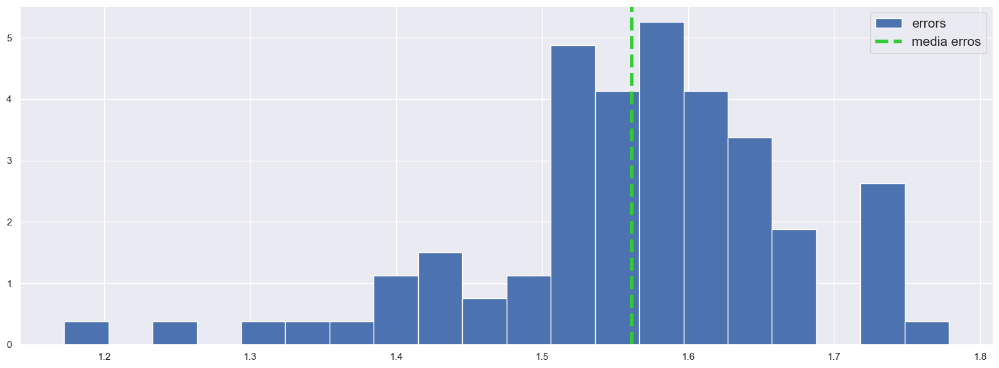

In [79]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


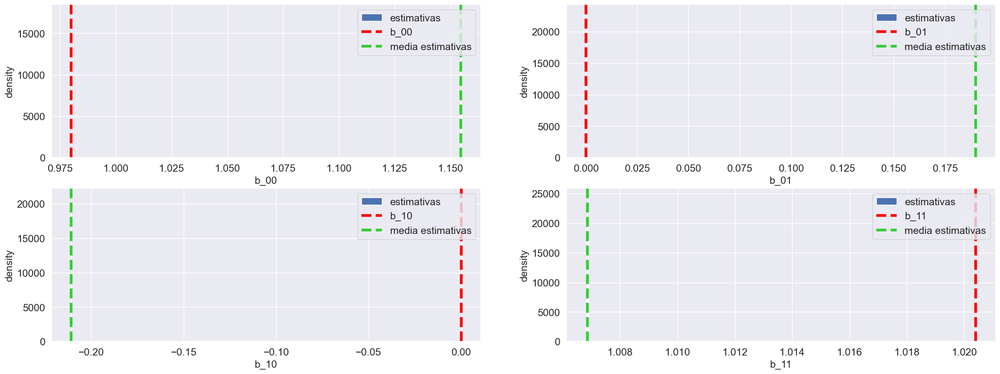

In [80]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.24
####################################################################################################


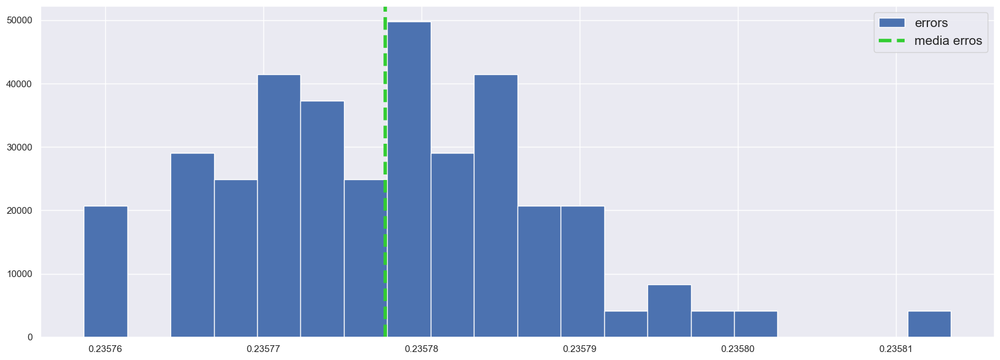

In [81]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## x.

In [82]:
test_case='x'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


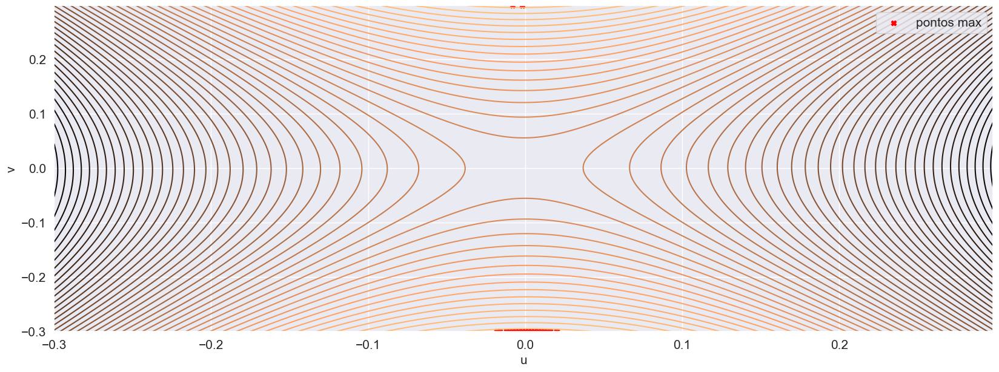

In [83]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


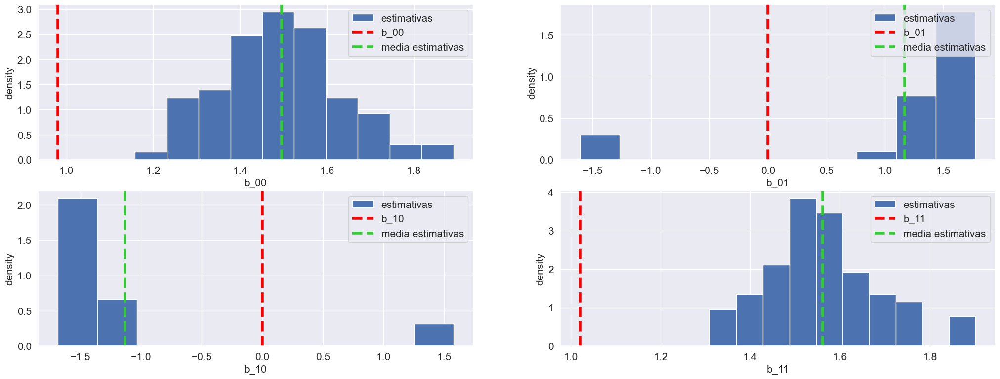

In [84]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 1.56
Max error: 1.75
Min error: 1.35
####################################################################################################


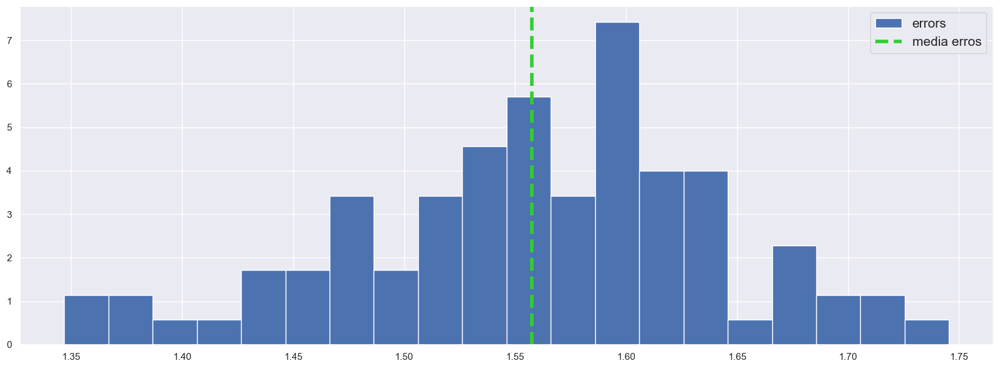

In [85]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


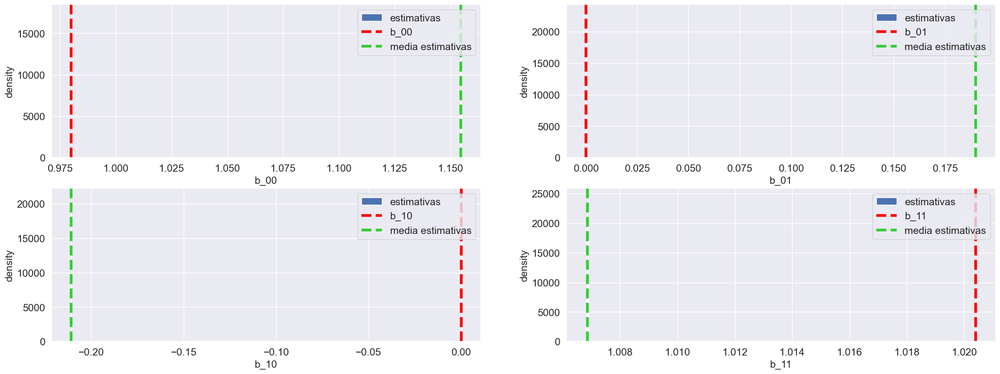

In [86]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.24
####################################################################################################


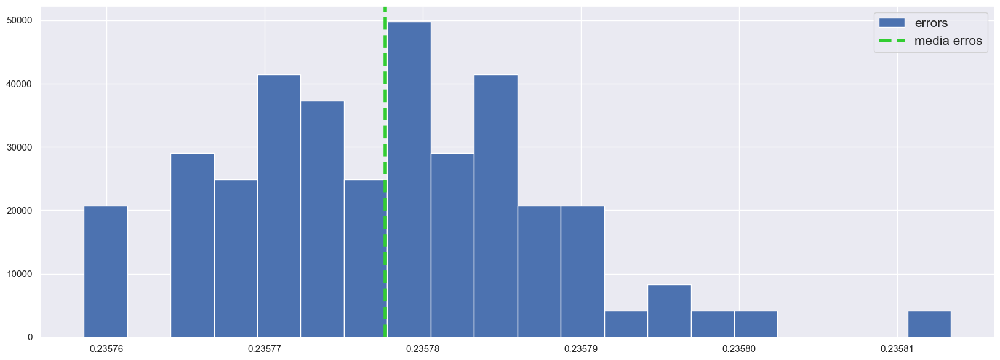

In [87]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## xi.

In [88]:
test_case='xi'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


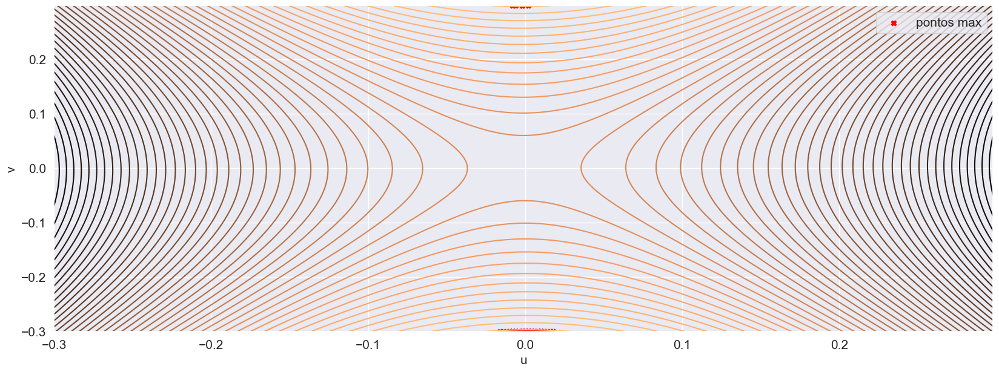

In [89]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


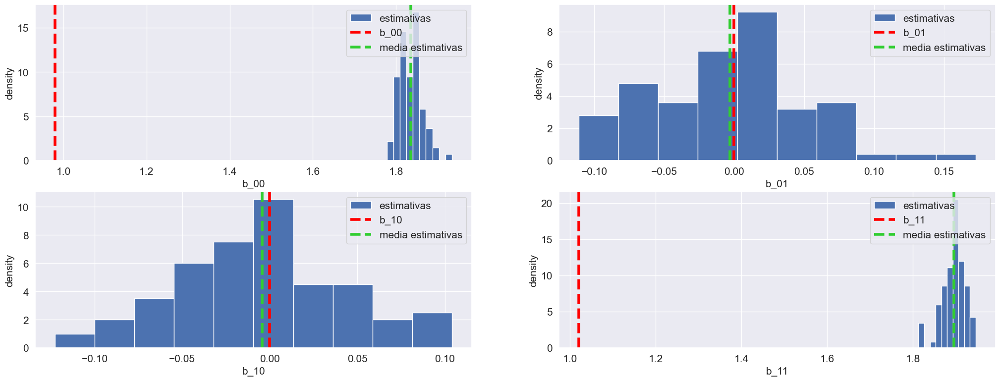

In [90]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.87
Max error: 0.91
Min error: 0.82
####################################################################################################


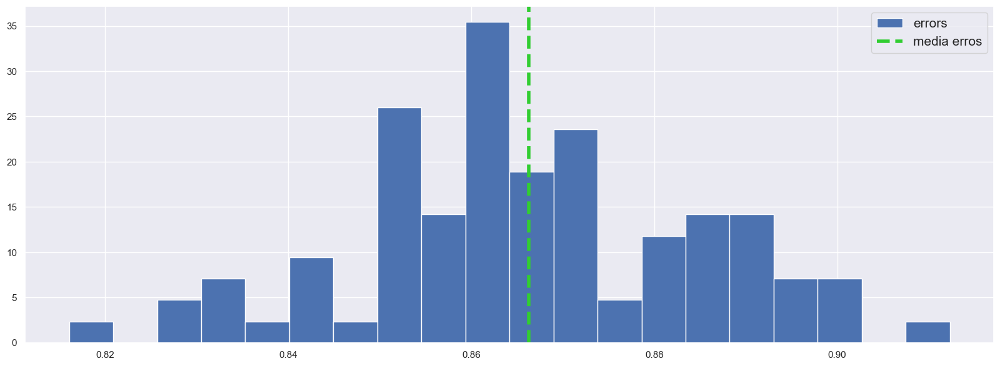

In [91]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


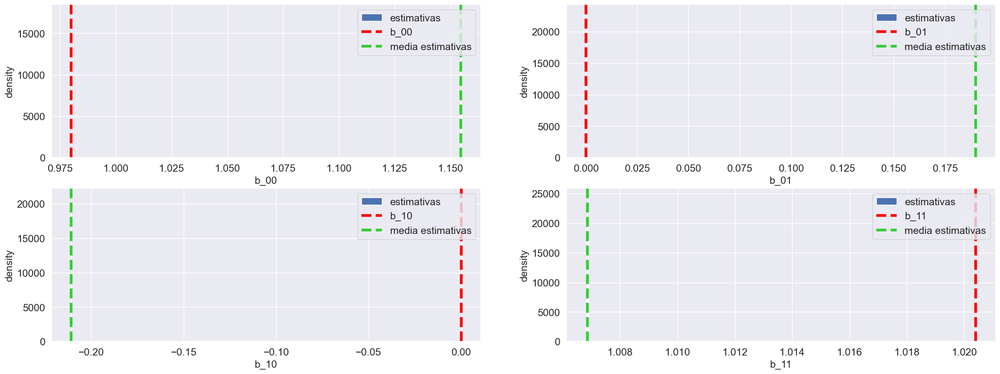

In [92]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.24
####################################################################################################


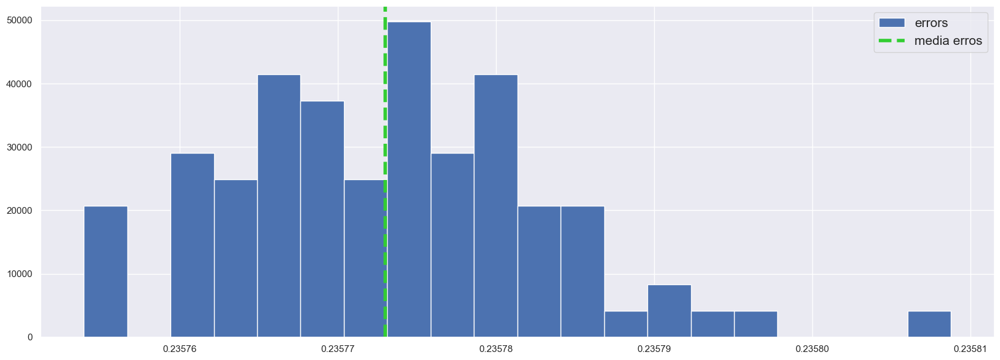

In [93]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)

## xii.

In [94]:
test_case='xii'

### Posterior contours

----------------------------------------------------------------------------------------------------
Normalized log-posterior (average)
----------------------------------------------------------------------------------------------------


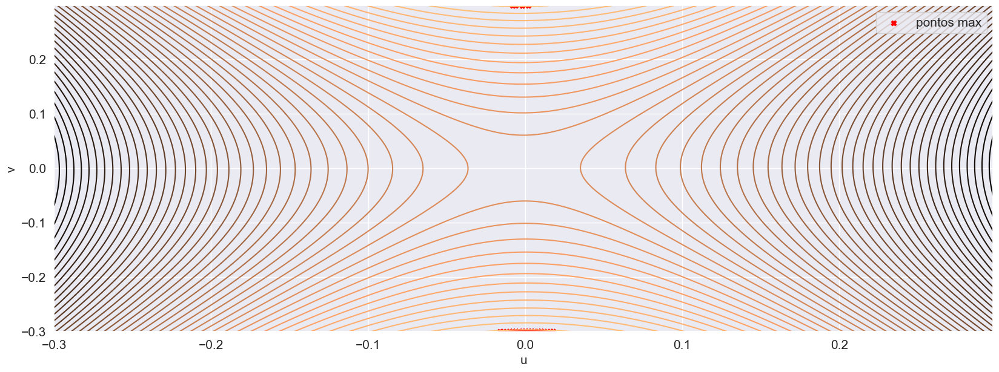

In [95]:
EstimationGraphPlotter.plot_2D_contours(
    u_vec=parser.parsed_results[test_case]['posteriori_grid']['u_vec'],
    v_vec=parser.parsed_results[test_case]['posteriori_grid']['v_vec'],
    z=parser.parsed_results[test_case]['posteriori_grid']['average_grid'],
    max_us=parser.parsed_results[test_case]['posteriori_grid']['u_max'],
    max_vs=parser.parsed_results[test_case]['posteriori_grid']['v_max'],
)

### MMSE estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


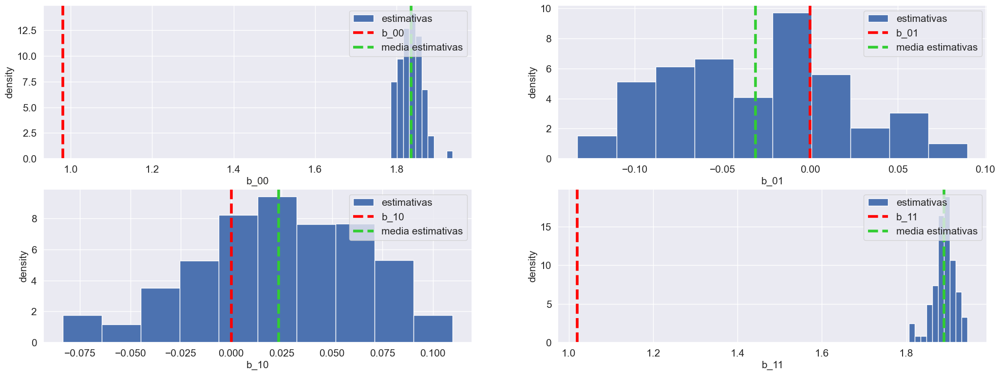

In [96]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['mmse']['b11_estimates'],
        parser.parsed_results[test_case]['mmse']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['mmse']['b21_estimates'],
        parser.parsed_results[test_case]['mmse']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MMSE estimation errors

####################################################################################################
Mean error: 0.86
Max error: 0.91
Min error: 0.82
####################################################################################################


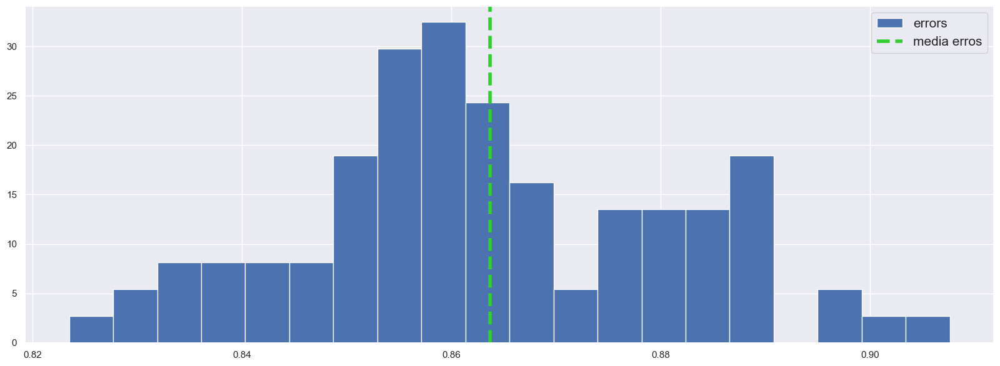

In [97]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['mmse']['errors'],
    nbins=20
)

### MAP estimations

----------------------------------------------------------------------------------------------------
(a) B11
(b) B12
(c) B21
(d) B22
----------------------------------------------------------------------------------------------------


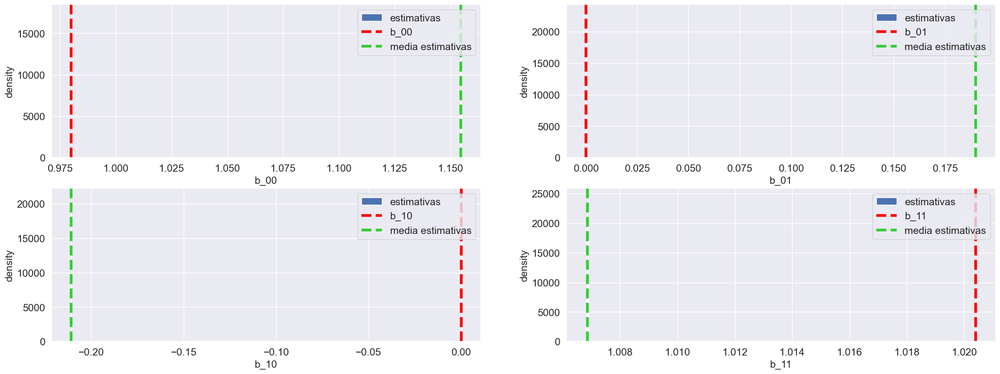

In [98]:
# Get estimates as square matrix
estimates = np.array([
    [
        parser.parsed_results[test_case]['map']['b11_estimates'],
        parser.parsed_results[test_case]['map']['b12_estimates']
    ],
    [
        parser.parsed_results[test_case]['map']['b21_estimates'],
        parser.parsed_results[test_case]['map']['b22_estimates']
    ]
])

# Plot
EstimationGraphPlotter.estimation_distributions(
    B_true=parser.execution_config['general']['B'],
    estimates=estimates,
    nbins=10,
    save_dir=None,
    ylims=None,
    xlims=None,
    label_size=15,
    tick_size=15,
    legend_size=15,
    plot_estimate=True,
    plot_true_value=True
)

### MAP estimation errors

####################################################################################################
Mean error: 0.24
Max error: 0.24
Min error: 0.24
####################################################################################################


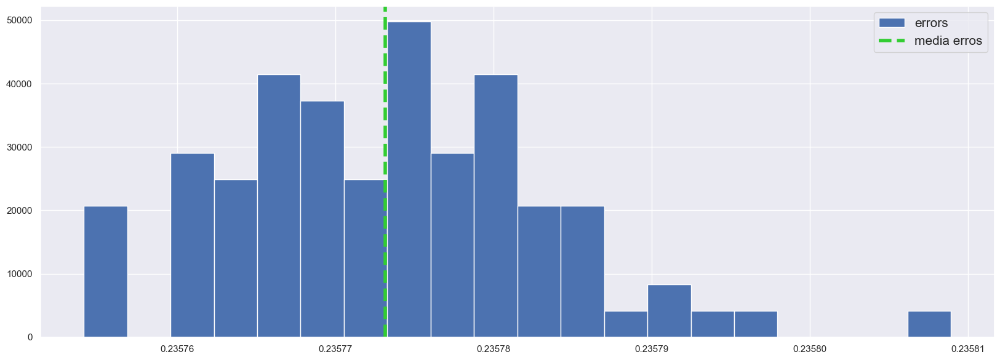

In [99]:
EstimationGraphPlotter.plot_estimation_errors(
    errors=parser.parsed_results[test_case]['map']['errors'],
    nbins=20
)